# Parkinson MRI Late Fusion — Image-Level Matched 35-Epoch Pipeline

This notebook is the image-level counterpart of the patient-level
late-fusion experiment.

## Matched training configuration

Each base CNN uses:

- `include_top=False`
- 10 frozen-backbone head-training epochs
- 25 partial fine-tuning epochs
- 35 total configured epochs

The final selected backbone layers are trainable during the 25
fine-tuning epochs:

- VGG16: last 8 non-Batch-Normalization layers
- DenseNet121: last 30 non-Batch-Normalization layers
- MobileNetV2: last 20 non-Batch-Normalization layers

The global trainable-weight fusion model and sample-wise attention
fusion model each use 35 epochs.

## Included late-fusion methods

1. VGG16
2. DenseNet121
3. MobileNetV2
4. Equal-average late fusion
5. Manual weighted late fusion
6. Development-grid weighted late fusion
7. Global trainable-weight late fusion
8. Sample-wise attention late fusion
9. Logistic-regression stacking

## Important evaluation definition

This is an **image-level** experiment. Individual MRI images are split
60/20/20. Exact images do not overlap, but slices belonging to the same
patient may occur in multiple partitions. Keep these results separate
from the patient-level experiment in the paper.

In [14]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install -q scikit-learn pandas pillow joblib openpyxl

In [16]:
import os, re, gc, json, shutil, hashlib, zipfile, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, DenseNet121, MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("GPU warning:", error)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Image-level experiment configuration

In [17]:
ZIP_PATH = Path(
    "/content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_dataset_here/Parkinson_dataset.zip"
)

# Extract locally for faster and more stable training reads.
LOCAL_EXTRACT_DIR = Path(
    "/content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_dataset_unzip_here"
)

SAVE_ROOT = Path(
    "/content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here"
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

TRAIN_RATIO = 0.60
DEVELOPMENT_RATIO = 0.20
TEST_RATIO = 0.20

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
TOTAL_BASE_MODEL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS
HEAD_LR = 1e-4
FINE_TUNE_LR = 5e-6
USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 7

UNFREEZE_LAST_N = {
    "VGG16": 8,
    "DenseNet121": 30,
    "MobileNetV2": 20,
}

REUSE_IMAGE_LEVEL_MODELS = True

GLOBAL_FUSION_EPOCHS = 35
ATTENTION_FUSION_EPOCHS = 35

MANUAL_WEIGHTS = np.array(
    [0.25, 0.50, 0.25],
    dtype=np.float32,
)

CLASS_NAMES = [
    "healthy_dataset",
    "parkinson_dataset",
]

CLASS_INDICES = {
    "healthy_dataset": 0,
    "parkinson_dataset": 1,
}

SUPPORTED_EXTENSIONS = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
)

MODELS_DIR = SAVE_ROOT / "models"
FUSION_DIR = SAVE_ROOT / "fusion_models"
PREDICTIONS_DIR = SAVE_ROOT / "predictions"
REPORTS_DIR = SAVE_ROOT / "reports"
CONFUSION_DIR = SAVE_ROOT / "confusion_matrices"
GRAPHS_DIR = SAVE_ROOT / "graphs"
ROC_DIR = SAVE_ROOT / "roc_npz"
GRADCAM_DIR = SAVE_ROOT / "gradcam"
HISTORY_DIR = SAVE_ROOT / "history"
TABLES_DIR = SAVE_ROOT / "tables"
SPLIT_DIR = SAVE_ROOT / "image_split"

for folder in [
    SAVE_ROOT,
    MODELS_DIR,
    FUSION_DIR,
    PREDICTIONS_DIR,
    REPORTS_DIR,
    CONFUSION_DIR,
    GRAPHS_DIR,
    ROC_DIR,
    GRADCAM_DIR,
    HISTORY_DIR,
    TABLES_DIR,
    SPLIT_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

IMAGE_SPLIT_PATH = (
    SPLIT_DIR
    / "image_level_split_assignments.csv"
)

MASTER_SPLIT_PATH = (
    SPLIT_DIR
    / "parkinson_master_image_level_split.csv"
)

print("Image-level output:", SAVE_ROOT)
print("Early stopping enabled:", USE_EARLY_STOPPING)
print(
    "Base-model epochs:",
    HEAD_EPOCHS + FINE_TUNE_EPOCHS,
)

# Training checkpoints are written locally in Colab first.
# Completed files are then copied to Google Drive with retry protection.
LOCAL_RUNTIME_ROOT = Path(
    "/content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/late_fusion_data_results_here"
)
LOCAL_MODELS_DIR = LOCAL_RUNTIME_ROOT / "models"
LOCAL_HISTORY_DIR = LOCAL_RUNTIME_ROOT / "history"
LOCAL_BACKUP_DIR = LOCAL_RUNTIME_ROOT / "training_backups"
LOCAL_FUSION_DIR = LOCAL_RUNTIME_ROOT / "fusion_models"

for folder in [
    LOCAL_RUNTIME_ROOT,
    LOCAL_MODELS_DIR,
    LOCAL_HISTORY_DIR,
    LOCAL_BACKUP_DIR,
    LOCAL_FUSION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

assert TOTAL_BASE_MODEL_EPOCHS == 35
assert GLOBAL_FUSION_EPOCHS == 35
assert ATTENTION_FUSION_EPOCHS == 35

print("Base-model schedule:", HEAD_EPOCHS, "+", FINE_TUNE_EPOCHS)
print("Total CNN epochs:", TOTAL_BASE_MODEL_EPOCHS)
print("Global fusion epochs:", GLOBAL_FUSION_EPOCHS)
print("Attention fusion epochs:", ATTENTION_FUSION_EPOCHS)

Image-level output: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here
Early stopping enabled: False
Base-model epochs: 35
Base-model schedule: 10 + 25
Total CNN epochs: 35
Global fusion epochs: 35
Attention fusion epochs: 35


## Serializable preprocessing and fusion layers

In [18]:
@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class VGG16Preprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.vgg16.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class DenseNetPreprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class MobileNetV2Preprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class GlobalTrainableFusion(layers.Layer):
    def __init__(self, number_of_models=3, **kwargs):
        super().__init__(**kwargs)
        self.number_of_models = number_of_models

    def build(self, input_shape):
        self.raw_weights = self.add_weight(
            name="raw_fusion_weights",
            shape=(self.number_of_models,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        weights = tf.nn.softmax(self.raw_weights)
        return tf.reduce_sum(inputs * weights, axis=1, keepdims=True)

    def get_config(self):
        config = super().get_config()
        config.update({"number_of_models": self.number_of_models})
        return config

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class AttentionWeightedSum(layers.Layer):
    def call(self, inputs):
        probabilities, weights = inputs
        return tf.reduce_sum(
            probabilities * weights,
            axis=1,
            keepdims=True
        )

CUSTOM_OBJECTS = {
    "VGG16Preprocess": VGG16Preprocess,
    "DenseNetPreprocess": DenseNetPreprocess,
    "MobileNetV2Preprocess": MobileNetV2Preprocess,
    "GlobalTrainableFusion": GlobalTrainableFusion,
    "AttentionWeightedSum": AttentionWeightedSum
}

## Extract the dataset and create the image-level manifest

In [19]:
def count_supported_images(directory):
    directory = Path(directory)

    return sum(
        1
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower()
        in SUPPORTED_EXTENSIONS
        and "__MACOSX" not in path.parts
    )


def locate_dataset_root(search_root):
    search_root = Path(search_root)

    candidates = [search_root]
    candidates.extend(
        path
        for path in search_root.rglob("*")
        if path.is_dir()
        and "__MACOSX" not in path.parts
    )

    valid_candidates = []

    for candidate in candidates:
        healthy_dir = (
            candidate / "healthy_dataset"
        )
        parkinson_dir = (
            candidate / "parkinson_dataset"
        )

        if not (
            healthy_dir.is_dir()
            and parkinson_dir.is_dir()
        ):
            continue

        healthy_count = count_supported_images(
            healthy_dir
        )
        parkinson_count = count_supported_images(
            parkinson_dir
        )

        valid_candidates.append(
            {
                "path": candidate,
                "healthy_images": healthy_count,
                "parkinson_images": (
                    parkinson_count
                ),
                "total_images": (
                    healthy_count
                    + parkinson_count
                ),
            }
        )

    if not valid_candidates:
        raise FileNotFoundError(
            "No folder containing both class "
            f"directories was found under {search_root}"
        )

    candidate_table = pd.DataFrame(
        [
            {
                "candidate_root": str(
                    item["path"]
                ),
                "healthy_images": (
                    item["healthy_images"]
                ),
                "parkinson_images": (
                    item["parkinson_images"]
                ),
                "total_images": (
                    item["total_images"]
                ),
            }
            for item in valid_candidates
        ]
    ).sort_values(
        "total_images",
        ascending=False,
    )

    display(candidate_table)

    non_empty = [
        item
        for item in valid_candidates
        if (
            item["healthy_images"] > 0
            and item["parkinson_images"] > 0
        )
    ]

    if not non_empty:
        raise RuntimeError(
            "Class folders were found, but valid "
            "image counts were zero."
        )

    selected = max(
        non_empty,
        key=lambda item: (
            item["total_images"],
            min(
                item["healthy_images"],
                item["parkinson_images"],
            ),
        ),
    )

    print(
        "Selected dataset root:",
        selected["path"],
    )

    return selected["path"]


if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP not found: {ZIP_PATH}"
    )

extract_required = True

if LOCAL_EXTRACT_DIR.exists():
    try:
        DATASET_ROOT = locate_dataset_root(
            LOCAL_EXTRACT_DIR
        )
        extract_required = False
    except (
        FileNotFoundError,
        RuntimeError,
        zipfile.BadZipFile,
    ):
        shutil.rmtree(
            LOCAL_EXTRACT_DIR
        )

if extract_required:
    LOCAL_EXTRACT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        "r",
    ) as archive:
        archive.extractall(
            LOCAL_EXTRACT_DIR
        )

    # Extract ZIP files nested inside the main ZIP.
    processed_nested_zips = set()

    while True:
        nested_zips = [
            path
            for path
            in LOCAL_EXTRACT_DIR.rglob("*.zip")
            if (
                path.is_file()
                and path not in processed_nested_zips
                and "__MACOSX" not in path.parts
            )
        ]

        if not nested_zips:
            break

        for nested_zip in nested_zips:
            nested_destination = (
                nested_zip.parent
                / nested_zip.stem
            )

            nested_destination.mkdir(
                parents=True,
                exist_ok=True,
            )

            with zipfile.ZipFile(
                nested_zip,
                "r",
            ) as archive:
                archive.extractall(
                    nested_destination
                )

            processed_nested_zips.add(
                nested_zip
            )

    DATASET_ROOT = locate_dataset_root(
        LOCAL_EXTRACT_DIR
    )


PATIENT_PATTERN = re.compile(
    r"(?:^|[/\\])PPMI[_-](\d+)",
    flags=re.IGNORECASE,
)

SLICE_PATTERN = re.compile(
    r"_(\d+)_S\d+_I\d+\.[^.]+$",
    flags=re.IGNORECASE,
)


def patient_id_from_path(filepath):
    match = PATIENT_PATTERN.search(
        str(filepath)
    )

    if not match:
        raise ValueError(
            "Cannot extract PPMI patient ID "
            f"from: {filepath}"
        )

    return str(match.group(1))


def slice_index_from_path(filepath):
    match = SLICE_PATTERN.search(
        Path(filepath).name
    )

    return (
        int(match.group(1))
        if match
        else np.nan
    )


records = []

for class_name in CLASS_NAMES:
    class_root = (
        DATASET_ROOT / class_name
    )

    if not class_root.is_dir():
        raise FileNotFoundError(
            class_root
        )

    for filepath in sorted(
        class_root.rglob("*")
    ):
        if (
            filepath.is_file()
            and filepath.suffix.lower()
            in SUPPORTED_EXTENSIONS
            and "__MACOSX"
            not in filepath.parts
        ):
            records.append(
                {
                    "filepath": str(filepath),
                    "filename": filepath.name,
                    "patient_id": (
                        patient_id_from_path(
                            filepath
                        )
                    ),
                    "slice_index": (
                        slice_index_from_path(
                            filepath
                        )
                    ),
                    "class_name": class_name,
                    "label": (
                        CLASS_INDICES[
                            class_name
                        ]
                    ),
                }
            )


all_images_df = (
    pd.DataFrame(records)
    .sort_values(
        ["label", "patient_id", "filepath"]
    )
    .reset_index(drop=True)
)

if all_images_df.empty:
    raise RuntimeError(
        "No MRI images were found."
    )

if all_images_df[
    "filepath"
].duplicated().any():
    raise RuntimeError(
        "Duplicate image paths were found."
    )

if not all(
    Path(path).exists()
    for path in all_images_df[
        "filepath"
    ]
):
    raise FileNotFoundError(
        "At least one collected image "
        "path does not exist."
    )

label_counts_per_patient = (
    all_images_df.groupby(
        "patient_id"
    )["label"].nunique()
)

if (
    label_counts_per_patient > 1
).any():
    raise RuntimeError(
        "A patient occurs in both classes."
    )

dataset_summary = (
    all_images_df.groupby(
        "class_name",
        as_index=False,
    )
    .agg(
        images=(
            "filepath",
            "size",
        ),
        patients=(
            "patient_id",
            "nunique",
        ),
    )
)

print("Dataset root:", DATASET_ROOT)
print("Images:", len(all_images_df))
print(
    "Patients:",
    all_images_df[
        "patient_id"
    ].nunique(),
)
display(dataset_summary)

,candidate_root,healthy_images,parkinson_images,total_images
0,/content/drive/MyDrive/New_image_level_updated...,5560,5560,11120


Selected dataset root: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_dataset_unzip_here/Parkinson_dataset
Dataset root: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_dataset_unzip_here/Parkinson_dataset
Images: 11120
Patients: 52


,class_name,images,patients
0,healthy_dataset,5560,23
1,parkinson_dataset,5560,29


## Create and verify the image-level train/development/test split

In [20]:
def create_image_level_split(images):
    if not np.isclose(
        TRAIN_RATIO
        + DEVELOPMENT_RATIO
        + TEST_RATIO,
        1.0,
    ):
        raise ValueError(
            "Split ratios must sum to 1."
        )

    train_development, test_images = (
        train_test_split(
            images,
            test_size=TEST_RATIO,
            random_state=SEED,
            stratify=images["label"],
        )
    )

    relative_development = (
        DEVELOPMENT_RATIO
        / (
            TRAIN_RATIO
            + DEVELOPMENT_RATIO
        )
    )

    (
        train_images,
        development_images,
    ) = train_test_split(
        train_development,
        test_size=relative_development,
        random_state=SEED,
        stratify=train_development[
            "label"
        ],
    )

    train_images = train_images.copy()
    development_images = (
        development_images.copy()
    )
    test_images = test_images.copy()

    train_images["split"] = "train"
    development_images[
        "split"
    ] = "development"
    test_images["split"] = "test"

    return (
        pd.concat(
            [
                train_images,
                development_images,
                test_images,
            ],
            ignore_index=True,
        )
        .sort_values(
            ["split", "label", "filepath"]
        )
        .reset_index(drop=True)
    )


def validate_saved_image_split(
    split_table,
    current_images,
):
    split_table = split_table.copy()

    required_columns = {
        "filepath",
        "filename",
        "patient_id",
        "slice_index",
        "class_name",
        "label",
        "split",
    }

    missing_columns = (
        required_columns
        - set(split_table.columns)
    )

    if missing_columns:
        raise RuntimeError(
            "Saved image split is missing "
            f"columns: {sorted(missing_columns)}"
        )

    if split_table[
        "filepath"
    ].duplicated().any():
        raise RuntimeError(
            "An image appears more than once "
            "in the saved split."
        )

    if set(
        split_table["filepath"]
    ) != set(
        current_images["filepath"]
    ):
        raise RuntimeError(
            "Saved image assignments do not "
            "match the current dataset."
        )

    if set(
        split_table["split"]
    ) != {
        "train",
        "development",
        "test",
    }:
        raise RuntimeError(
            "Invalid split names in the "
            "saved image assignment."
        )

    current_labels = (
        current_images.set_index(
            "filepath"
        )["label"].astype(int)
    )

    saved_labels = (
        split_table.set_index(
            "filepath"
        )["label"].astype(int)
    )

    saved_labels = saved_labels.loc[
        current_labels.index
    ]

    if not np.array_equal(
        current_labels.to_numpy(),
        saved_labels.to_numpy(),
    ):
        raise RuntimeError(
            "Saved and current image labels "
            "differ."
        )

    return (
        split_table.sort_values(
            ["split", "label", "filepath"]
        )
        .reset_index(drop=True)
    )


if IMAGE_SPLIT_PATH.exists():
    try:
        master_df = pd.read_csv(
            IMAGE_SPLIT_PATH,
            dtype={
                "patient_id": str,
            },
        )

        master_df = (
            validate_saved_image_split(
                master_df,
                all_images_df,
            )
        )

        print(
            "Reusing saved image-level split."
        )

    except Exception as error:
        print(
            "Saved image split was not reusable:",
            error,
        )

        master_df = (
            create_image_level_split(
                all_images_df
            )
        )

        master_df.to_csv(
            IMAGE_SPLIT_PATH,
            index=False,
        )

        print(
            "Created a new image-level split."
        )

else:
    master_df = (
        create_image_level_split(
            all_images_df
        )
    )

    master_df.to_csv(
        IMAGE_SPLIT_PATH,
        index=False,
    )

    print(
        "Created a new image-level split."
    )


train_df = (
    master_df[
        master_df["split"]
        == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

development_df = (
    master_df[
        master_df["split"]
        == "development"
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    master_df[
        master_df["split"]
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)


train_images = set(
    train_df["filepath"]
)

development_images = set(
    development_df["filepath"]
)

test_images = set(
    test_df["filepath"]
)

if train_images & development_images:
    raise RuntimeError(
        "Image overlap between training "
        "and development."
    )

if train_images & test_images:
    raise RuntimeError(
        "Image overlap between training "
        "and testing."
    )

if development_images & test_images:
    raise RuntimeError(
        "Image overlap between development "
        "and testing."
    )

if (
    len(train_df)
    + len(development_df)
    + len(test_df)
    != len(master_df)
):
    raise RuntimeError(
        "Split image counts do not sum "
        "to the full dataset."
    )


MASTER_SPLIT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

master_df.to_csv(
    MASTER_SPLIT_PATH,
    index=False,
)


fingerprint_source = (
    master_df[
        ["filepath", "label", "split"]
    ]
    .astype(str)
    .sort_values(
        ["filepath", "split"]
    )
)

SPLIT_FINGERPRINT = (
    hashlib.sha256(
        pd.util.hash_pandas_object(
            fingerprint_source,
            index=False,
        ).values.tobytes()
    )
    .hexdigest()[:20]
)


split_summary = (
    master_df.groupby(
        ["split", "class_name"],
        as_index=False,
    )
    .agg(
        images=(
            "filepath",
            "size",
        ),
        unique_patients=(
            "patient_id",
            "nunique",
        ),
    )
)

display(split_summary)

train_patient_ids = set(
    train_df["patient_id"]
)

development_patient_ids = set(
    development_df["patient_id"]
)

test_patient_ids = set(
    test_df["patient_id"]
)

patient_overlap_summary = {
    "train_development": len(
        train_patient_ids
        & development_patient_ids
    ),
    "train_test": len(
        train_patient_ids
        & test_patient_ids
    ),
    "development_test": len(
        development_patient_ids
        & test_patient_ids
    ),
}

print(
    "Train/development image overlap: 0"
)
print("Train/test image overlap: 0")
print(
    "Development/test image overlap: 0"
)
print(
    "Patient overlap is allowed in this "
    "image-level experiment:",
    patient_overlap_summary,
)
print(
    "Total images included:",
    len(master_df),
)
print("Images excluded: 0")
print(
    "Image split fingerprint:",
    SPLIT_FINGERPRINT,
)
print(
    "IMAGE-LEVEL SPLIT CHECK: PASSED"
)

Reusing saved image-level split.


,split,class_name,images,unique_patients
0,development,healthy_dataset,1112,23
1,development,parkinson_dataset,1112,29
2,test,healthy_dataset,1112,23
3,test,parkinson_dataset,1112,29
4,train,healthy_dataset,3336,23
5,train,parkinson_dataset,3336,29


Train/development image overlap: 0
Train/test image overlap: 0
Development/test image overlap: 0
Patient overlap is allowed in this image-level experiment: {'train_development': 52, 'train_test': 52, 'development_test': 52}
Total images included: 11120
Images excluded: 0
Image split fingerprint: fcc9976abdc6803bf00c
IMAGE-LEVEL SPLIT CHECK: PASSED


## Deterministic TensorFlow datasets for the image-level split

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(filepath, label):
    image = tf.io.decode_image(
        tf.io.read_file(filepath),
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE, antialias=True)
    return tf.cast(image, tf.float32), tf.cast(label, tf.float32)

def create_dataset(dataframe, training=False):
    dataframe = dataframe.reset_index(drop=True)
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].astype(str).to_numpy(),
        dataframe["label"].to_numpy(dtype=np.float32)
    ))

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)

    if training:
        dataset = dataset.shuffle(
            len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        decode_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=True
    )
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, training=True)
development_ds = create_dataset(development_df)
test_ds = create_dataset(test_df)

class_weight_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(dtype=np.int32)
)
CLASS_WEIGHTS = {
    0: float(class_weight_array[0]),
    1: float(class_weight_array[1])
}

sample_images, sample_labels = next(iter(train_ds))
if not np.all(np.isfinite(sample_images.numpy())):
    raise FloatingPointError("Decoded images contain invalid values.")

print("Class weights:", CLASS_WEIGHTS)
print("Sample batch:", sample_images.shape, sample_labels.shape)
print("INPUT PIPELINE CHECK: PASSED")

Class weights: {0: 1.0, 1: 1.0}
Sample batch: (16, 224, 224, 3) (16,)
INPUT PIPELINE CHECK: PASSED


## Build, train and safely reuse image-level base models

In [22]:

def copy_file_with_retry(
    source,
    destination,
    attempts=5,
    initial_delay_seconds=2,
):
    source = Path(source)
    destination = Path(destination)

    if not source.exists():
        raise FileNotFoundError(
            f"Source file does not exist: {source}"
        )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    delay = initial_delay_seconds
    last_error = None

    for attempt in range(1, attempts + 1):
        temporary_destination = destination.with_name(
            destination.name + ".copying"
        )

        try:
            if temporary_destination.exists():
                temporary_destination.unlink()

            shutil.copy2(
                source,
                temporary_destination,
            )

            temporary_destination.replace(destination)

            if (
                not destination.exists()
                or destination.stat().st_size
                != source.stat().st_size
            ):
                raise IOError(
                    "Copied file failed size verification."
                )

            return destination

        except Exception as error:
            last_error = error

            if temporary_destination.exists():
                try:
                    temporary_destination.unlink()
                except OSError:
                    pass

            print(
                f"Drive copy attempt {attempt}/{attempts} failed "
                f"for {destination.name}: {error}"
            )

            if attempt < attempts:
                time.sleep(delay)
                delay *= 2

    raise IOError(
        f"Unable to synchronize {source} to {destination}"
    ) from last_error


def write_text_locally_and_sync(
    text,
    local_path,
    drive_path,
):
    local_path = Path(local_path)
    local_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    local_path.write_text(
        text,
        encoding="utf-8",
    )
    copy_file_with_retry(
        local_path,
        drive_path,
    )


def ensure_checkpoint_exists(
    model,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        print(
            "No best checkpoint was produced; "
            "saving current weights as fallback."
        )
        model.save_weights(checkpoint_path)

    return checkpoint_path


def create_backbone(model_name):
    common = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (*IMG_SIZE, 3)
    }
    if model_name == "VGG16":
        return VGG16(**common, name="vgg16_backbone")
    if model_name == "DenseNet121":
        return DenseNet121(**common, name="densenet121_backbone")
    if model_name == "MobileNetV2":
        return MobileNetV2(**common, name="mobilenetv2_backbone")
    raise ValueError(model_name)

def preprocess_layer(model_name):
    if model_name == "VGG16":
        return VGG16Preprocess(name="vgg16_preprocess")
    if model_name == "DenseNet121":
        return DenseNetPreprocess(name="densenet121_preprocess")
    if model_name == "MobileNetV2":
        return MobileNetV2Preprocess(name="mobilenetv2_preprocess")
    raise ValueError(model_name)

def compile_base_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

def build_base_model(model_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image_input")
    x = keras.Sequential([
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(0.03, 0.03)
    ], name="augmentation")(inputs)

    x = preprocess_layer(model_name)(x)
    backbone = create_backbone(model_name)
    backbone.trainable = False
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
    x = layers.BatchNormalization(name="head_batch_norm")(x)
    x = layers.Dropout(0.35, name="head_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="head_dense_256")(x)
    x = layers.Dropout(0.25, name="head_dropout_2")(x)
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"{model_name}_image_level_classifier"
    )
    compile_base_model(model, HEAD_LR)
    return model

def find_backbone(model, model_name):
    expected = {
        "VGG16": "vgg16_backbone",
        "DenseNet121": "densenet121_backbone",
        "MobileNetV2": "mobilenetv2_backbone"
    }[model_name]

    try:
        return model.get_layer(expected)
    except ValueError:
        signature = {
            "VGG16": "block5_conv3",
            "DenseNet121": "conv5_block16_2_conv",
            "MobileNetV2": "Conv_1"
        }[model_name]

        for layer in model.layers:
            if isinstance(layer, keras.Model):
                if any(sub.name == signature for sub in layer.layers):
                    return layer
        raise ValueError(f"Could not find {model_name} backbone.")

def set_fine_tuning(model, model_name):
    backbone = find_backbone(model, model_name)
    backbone.trainable = True

    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers[-UNFREEZE_LAST_N[model_name]:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    trainable = [layer.name for layer in backbone.layers if layer.trainable]
    if not trainable:
        raise RuntimeError(f"No {model_name} layers were unfrozen.")
    print(model_name, "trainable backbone layers:", trainable)

def make_callbacks(model_name, stage):
    checkpoint = LOCAL_MODELS_DIR / (
        f"{model_name.lower()}_{stage}_best.weights.h5"
    )

    csv_log = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_{stage}.csv"
    )

    backup_directory = (
        LOCAL_BACKUP_DIR
        / model_name.lower()
        / stage
    )

    checkpoint.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    csv_log.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    backup_directory.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(checkpoint),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            str(csv_log),
            append=False
        ),
        keras.callbacks.BackupAndRestore(
            backup_dir=str(backup_directory),
            save_freq="epoch",
            delete_checkpoint=True
        )
    ]
    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=False,
                verbose=1
            )
        )
    return callbacks, checkpoint

def history_dict(history):
    return {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }

def load_model_safely(path):
    try:
        return keras.models.load_model(
            path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False,
            safe_mode=False
        )
    except TypeError:
        return keras.models.load_model(
            path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False
        )

def train_or_load_model(model_name):
    final_path = MODELS_DIR / (
        f"{model_name.lower()}_image_level_best.keras"
    )
    metadata_path = MODELS_DIR / (
        f"{model_name.lower()}_image_level_metadata.json"
    )
    history_path = HISTORY_DIR / (
        f"{model_name.lower()}_combined_history.json"
    )

    if (
        REUSE_IMAGE_LEVEL_MODELS
        and final_path.exists()
        and metadata_path.exists()
    ):
        metadata = json.loads(metadata_path.read_text())
        metadata_matches = (
            metadata.get("split_fingerprint") == SPLIT_FINGERPRINT
            and int(metadata.get("head_epochs", -1)) == HEAD_EPOCHS
            and int(metadata.get("fine_tune_epochs", -1)) == FINE_TUNE_EPOCHS
            and int(metadata.get("total_epochs", -1)) == TOTAL_BASE_MODEL_EPOCHS
        )

        if metadata_matches:
            model = load_model_safely(final_path)
            compile_base_model(model, FINE_TUNE_LR)
            history = (
                json.loads(history_path.read_text())
                if history_path.exists()
                else {}
            )
            print("Loaded image-level model:", final_path)
            return model, history

    tf.keras.backend.clear_session()
    gc.collect()

    # Clear stale local runtime files before a fresh 35-epoch run.
    for filename in [
        f"{model_name.lower()}_head_best.weights.h5",
        f"{model_name.lower()}_fine_tune_best.weights.h5",
        f"{model_name.lower()}_image_level_best.keras",
    ]:
        candidate = LOCAL_MODELS_DIR / filename
        if candidate.exists():
            candidate.unlink()

    for stage in ["head", "fine_tune"]:
        candidate_csv = (
            LOCAL_HISTORY_DIR
            / f"{model_name.lower()}_{stage}.csv"
        )
        if candidate_csv.exists():
            candidate_csv.unlink()

        candidate_backup = (
            LOCAL_BACKUP_DIR
            / model_name.lower()
            / stage
        )
        if candidate_backup.exists():
            shutil.rmtree(candidate_backup)

    model = build_base_model(model_name)
    test_output = model(
        tf.zeros((1, *IMG_SIZE, 3), dtype=tf.float32),
        training=False
    )
    if test_output.shape != (1, 1):
        raise RuntimeError(f"Bad model output shape: {test_output.shape}")

    head_callbacks, head_checkpoint = make_callbacks(model_name, "head")
    head_history_object = model.fit(
        train_ds,
        validation_data=development_ds,
        epochs=HEAD_EPOCHS,
        class_weight=CLASS_WEIGHTS,
        callbacks=head_callbacks,
        verbose=1
    )
    head_history = history_dict(head_history_object)

    head_checkpoint = ensure_checkpoint_exists(
        model,
        head_checkpoint,
    )
    model.load_weights(head_checkpoint)

    copy_file_with_retry(
        head_checkpoint,
        MODELS_DIR / head_checkpoint.name,
    )

    head_csv = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_head.csv"
    )
    if head_csv.exists():
        copy_file_with_retry(
            head_csv,
            HISTORY_DIR / head_csv.name,
        )

    set_fine_tuning(model, model_name)
    compile_base_model(model, FINE_TUNE_LR)

    fine_callbacks, fine_checkpoint = make_callbacks(
        model_name,
        "fine_tune"
    )
    fine_history_object = model.fit(
        train_ds,
        validation_data=development_ds,
        initial_epoch=HEAD_EPOCHS,
        epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
        class_weight=CLASS_WEIGHTS,
        callbacks=fine_callbacks,
        verbose=1
    )
    fine_history = history_dict(fine_history_object)

    fine_checkpoint = ensure_checkpoint_exists(
        model,
        fine_checkpoint,
    )

    copy_file_with_retry(
        fine_checkpoint,
        MODELS_DIR / fine_checkpoint.name,
    )

    fine_csv = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_fine_tune.csv"
    )
    if fine_csv.exists():
        copy_file_with_retry(
            fine_csv,
            HISTORY_DIR / fine_csv.name,
        )

    head_auc = float(np.nanmax(head_history.get("val_auc", [-np.inf])))
    fine_auc = float(np.nanmax(fine_history.get("val_auc", [-np.inf])))

    if fine_auc >= head_auc:
        model.load_weights(fine_checkpoint)
        selected_stage = "fine_tune"
        selected_auc = fine_auc
    else:
        model.load_weights(head_checkpoint)
        selected_stage = "head"
        selected_auc = head_auc

    local_final_path = (
        LOCAL_MODELS_DIR
        / final_path.name
    )

    model.save(local_final_path)

    copy_file_with_retry(
        local_final_path,
        final_path,
    )

    combined = {}
    for current in [
        head_history,
        fine_history,
    ]:
        for key, values in current.items():
            combined.setdefault(
                key,
                [],
            ).extend(values)

    if len(combined.get("loss", [])) != TOTAL_BASE_MODEL_EPOCHS:
        raise RuntimeError(
            f"{model_name}: expected {TOTAL_BASE_MODEL_EPOCHS} "
            f"epochs, received {len(combined.get('loss', []))}."
        )

    local_history_path = (
        LOCAL_HISTORY_DIR
        / history_path.name
    )

    write_text_locally_and_sync(
        json.dumps(
            combined,
            indent=2,
        ),
        local_history_path,
        history_path,
    )

    metadata = {
        "model_name": model_name,
        "split_fingerprint": SPLIT_FINGERPRINT,
        "selected_stage": selected_stage,
        "selected_validation_auc": selected_auc,
        "train_images": int(len(train_df)),
        "development_images": int(len(development_df)),
        "test_images": int(len(test_df)),
        "train_unique_patients": int(
            train_df["patient_id"].nunique()
        ),
        "development_unique_patients": int(
            development_df["patient_id"].nunique()
        ),
        "test_unique_patients": int(
            test_df["patient_id"].nunique()
        ),
        "include_top": False,
        "head_epochs": HEAD_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "total_epochs": TOTAL_BASE_MODEL_EPOCHS,
        "early_stopping_enabled": USE_EARLY_STOPPING,
        "checkpoint_storage": "local_colab_then_drive_sync",
    }

    local_metadata_path = (
        LOCAL_MODELS_DIR
        / metadata_path.name
    )

    write_text_locally_and_sync(
        json.dumps(
            metadata,
            indent=2,
        ),
        local_metadata_path,
        metadata_path,
    )

    print(
        "Saved matched 35-epoch image-level model:",
        final_path,
    )
    return model, combined

BASE_MODEL_NAMES = ["VGG16", "DenseNet121", "MobileNetV2"]
base_models = {}
base_histories = {}

for model_name in BASE_MODEL_NAMES:
    base_models[model_name], base_histories[model_name] = (
        train_or_load_model(model_name)
    )

Loaded image-level model: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/models/vgg16_image_level_best.keras
Loaded image-level model: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/models/densenet121_image_level_best.keras
Loaded image-level model: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/models/mobilenetv2_image_level_best.keras


## Base-model training history graphs

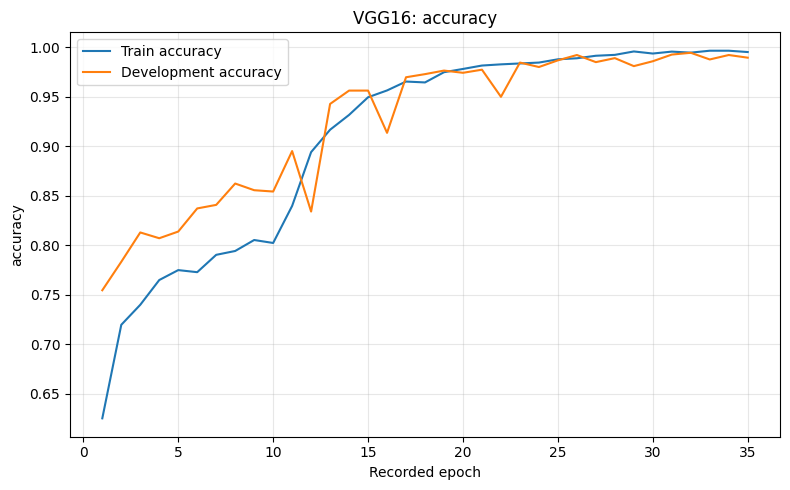

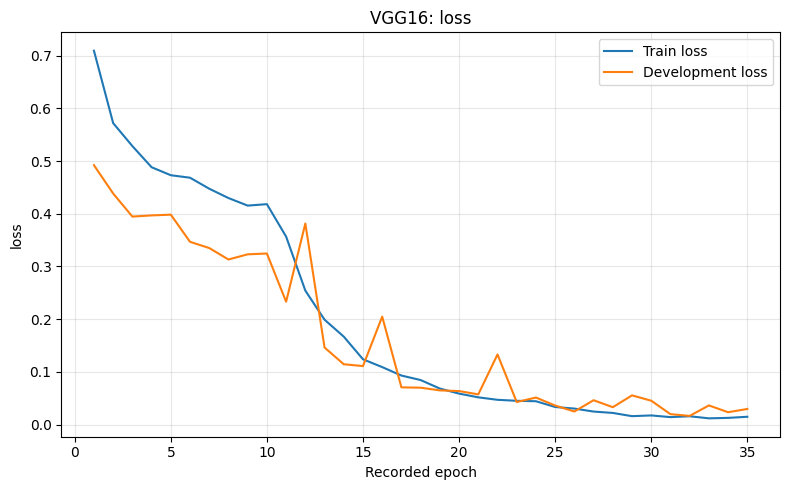

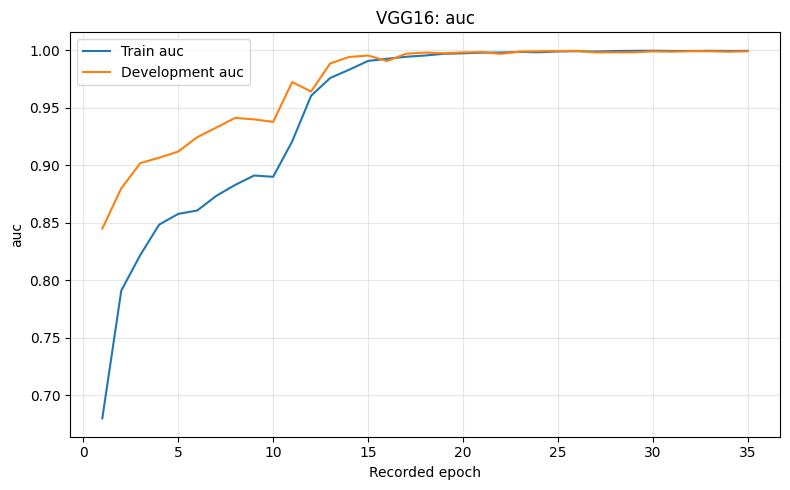

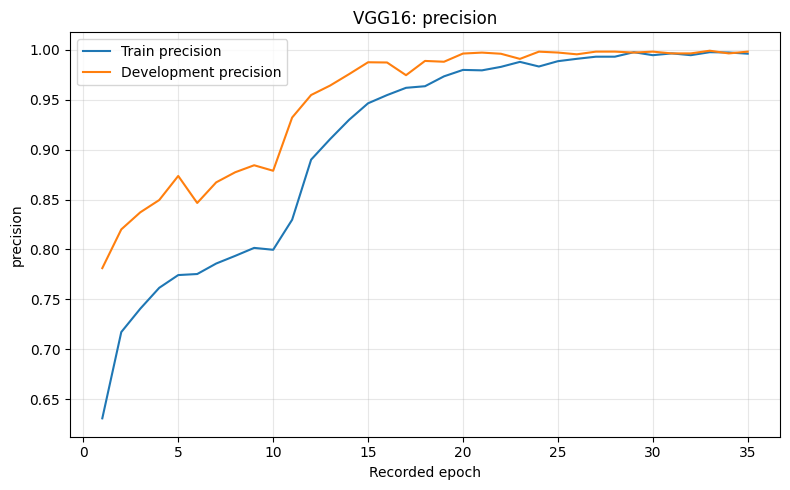

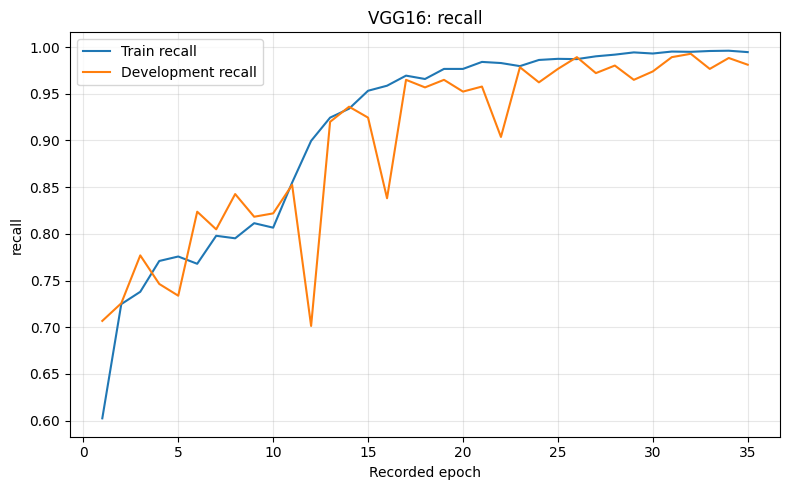

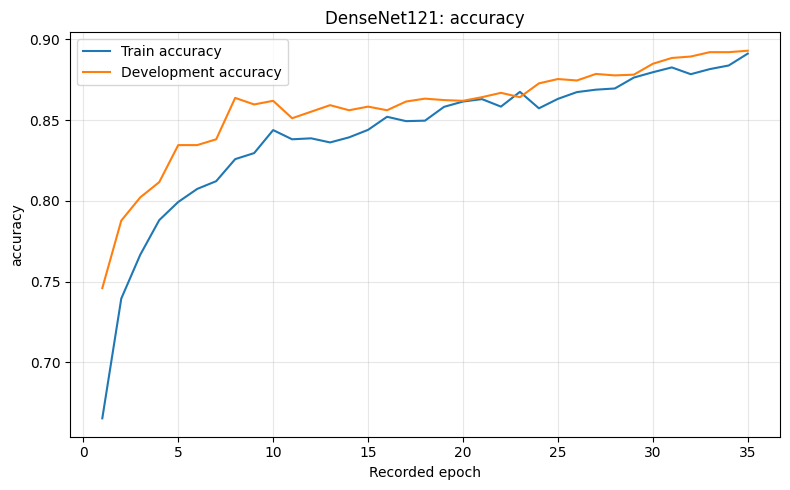

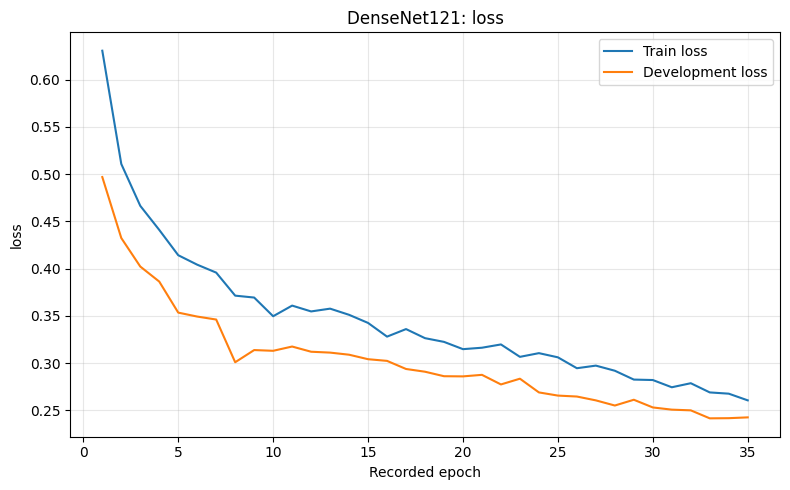

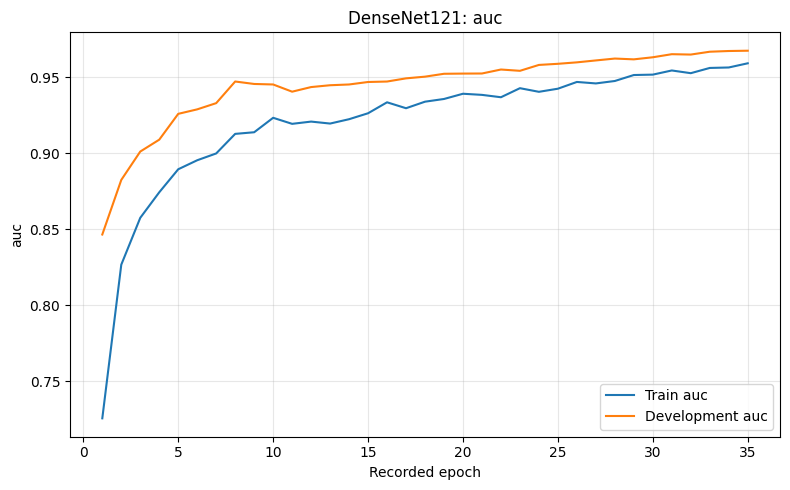

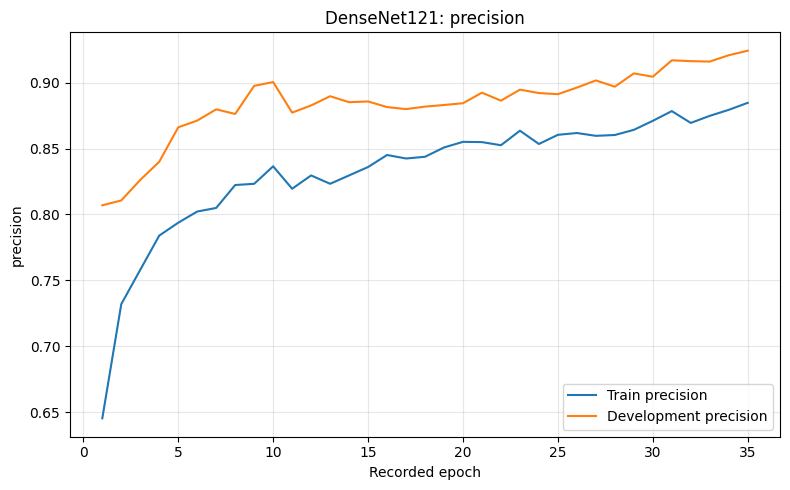

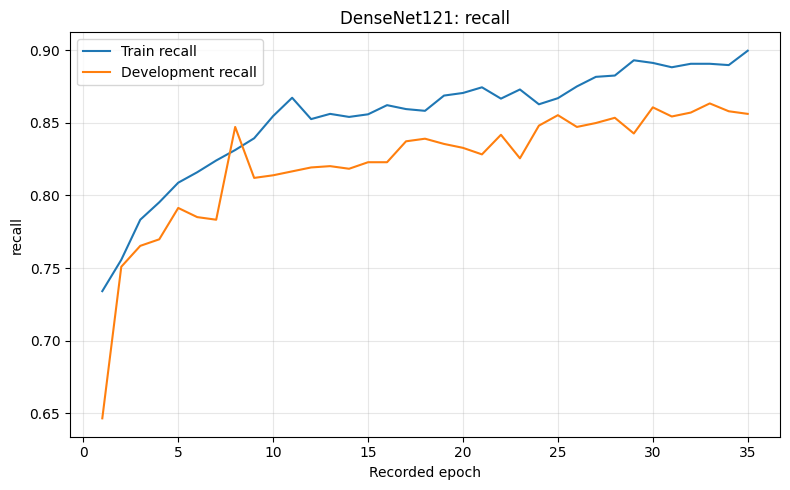

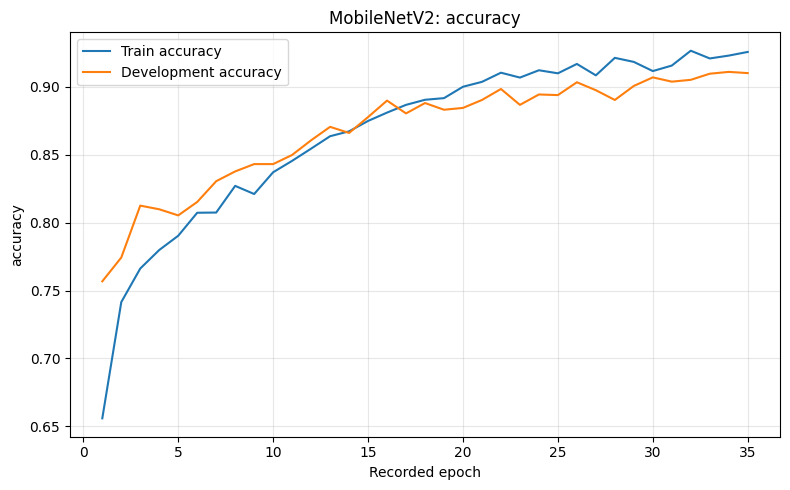

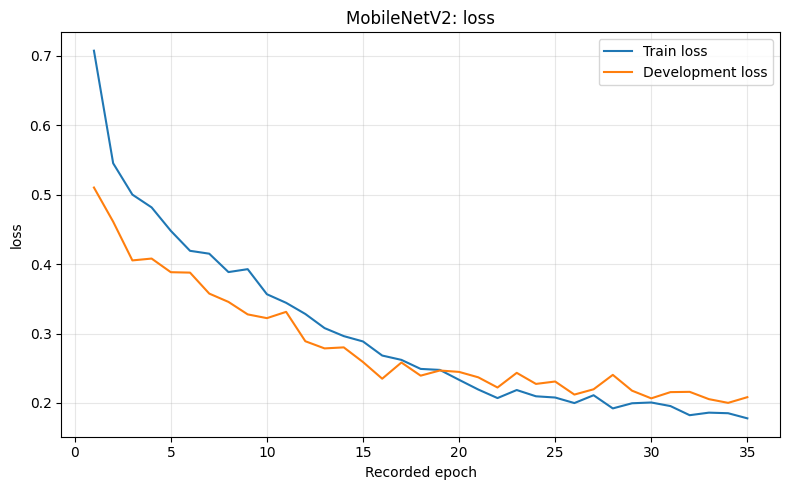

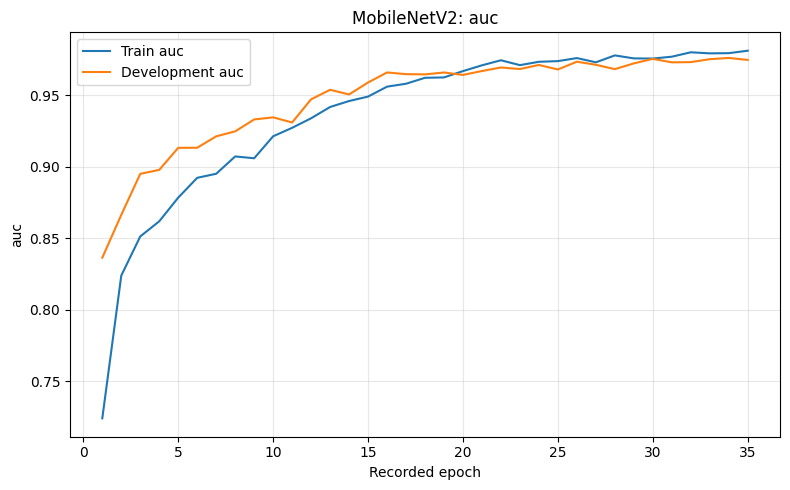

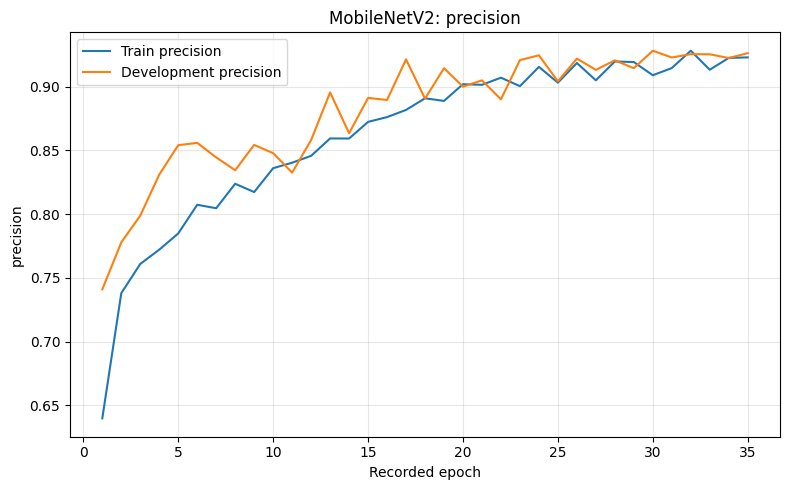

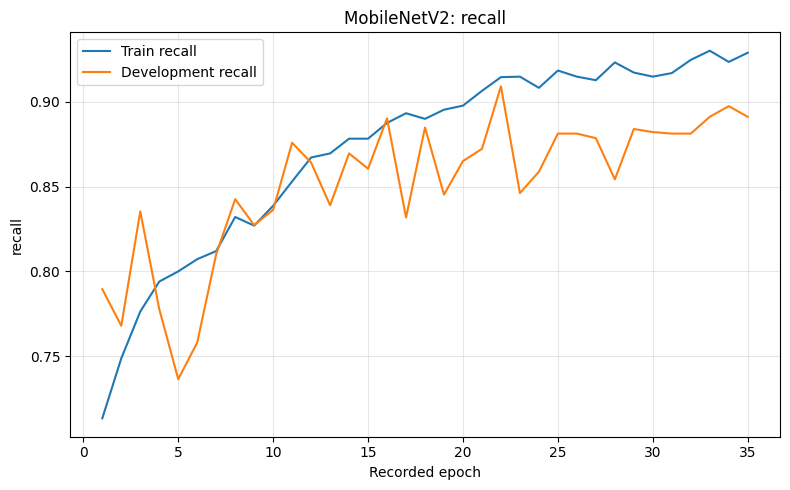

In [23]:
def plot_history(history, model_name, metric):
    train_values = history.get(metric, [])
    dev_values = history.get(f"val_{metric}", [])
    if not train_values or not dev_values:
        return

    epochs = np.arange(1, len(train_values) + 1)
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.plot(epochs, train_values, label=f"Train {metric}")
    axis.plot(epochs, dev_values, label=f"Development {metric}")
    axis.set_title(f"{model_name}: {metric}")
    axis.set_xlabel("Recorded epoch")
    axis.set_ylabel(metric)
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        GRAPHS_DIR / f"{model_name.lower()}_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)

for model_name, history in base_histories.items():
    for metric in ["accuracy", "loss", "auc", "precision", "recall"]:
        plot_history(history, model_name, metric)

## Generate aligned development and test image probabilities

In [24]:
def predict_probabilities(
    model,
    dataset,
    expected_count,
    name,
):
    probabilities = np.asarray(
        model.predict(
            dataset,
            verbose=1,
        ),
        dtype=np.float32,
    ).reshape(-1)

    if len(probabilities) != expected_count:
        raise RuntimeError(
            f"{name}: expected "
            f"{expected_count}, "
            f"got {len(probabilities)}"
        )

    if (
        not np.all(
            np.isfinite(
                probabilities
            )
        )
        or np.any(
            probabilities < 0
        )
        or np.any(
            probabilities > 1
        )
    ):
        raise ValueError(
            f"{name}: invalid probabilities"
        )

    return probabilities


development_table = (
    development_df[
        [
            "filepath",
            "filename",
            "patient_id",
            "slice_index",
            "label",
            "class_name",
            "split",
        ]
    ].copy()
)

test_table = (
    test_df[
        [
            "filepath",
            "filename",
            "patient_id",
            "slice_index",
            "label",
            "class_name",
            "split",
        ]
    ].copy()
)


probability_columns = {
    "VGG16": "vgg16_probability",
    "DenseNet121": (
        "densenet121_probability"
    ),
    "MobileNetV2": (
        "mobilenetv2_probability"
    ),
}


for model_name, column in (
    probability_columns.items()
):
    development_table[
        column
    ] = predict_probabilities(
        base_models[model_name],
        development_ds,
        len(development_df),
        (
            f"{model_name} "
            "development images"
        ),
    )

    test_table[
        column
    ] = predict_probabilities(
        base_models[model_name],
        test_ds,
        len(test_df),
        f"{model_name} test images",
    )


development_table.to_csv(
    PREDICTIONS_DIR
    / "development_image_base_probabilities.csv",
    index=False,
)

test_table.to_csv(
    PREDICTIONS_DIR
    / "test_image_base_probabilities.csv",
    index=False,
)


if set(
    development_table["filepath"]
) & set(
    test_table["filepath"]
):
    raise RuntimeError(
        "Image overlap in probability tables."
    )

if not np.array_equal(
    development_table[
        "label"
    ].to_numpy(),
    development_df[
        "label"
    ].to_numpy(),
):
    raise RuntimeError(
        "Development probability alignment failed."
    )

if not np.array_equal(
    test_table[
        "label"
    ].to_numpy(),
    test_df[
        "label"
    ].to_numpy(),
):
    raise RuntimeError(
        "Test probability alignment failed."
    )

print(
    "Development/test image overlap: 0"
)
print(
    "IMAGE PROBABILITY ALIGNMENT CHECK: PASSED"
)

139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 300ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
Development/test image overlap: 0
IMAGE PROBABILITY ALIGNMENT CHECK: PASSED


## Fit late-fusion methods using development images only

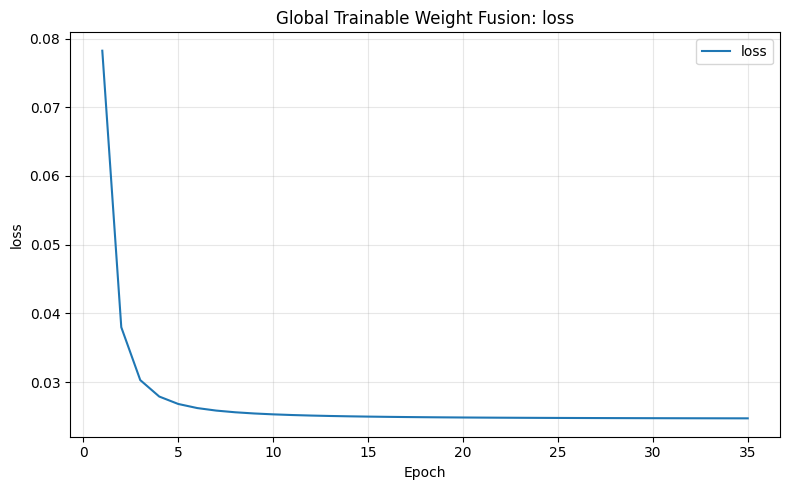

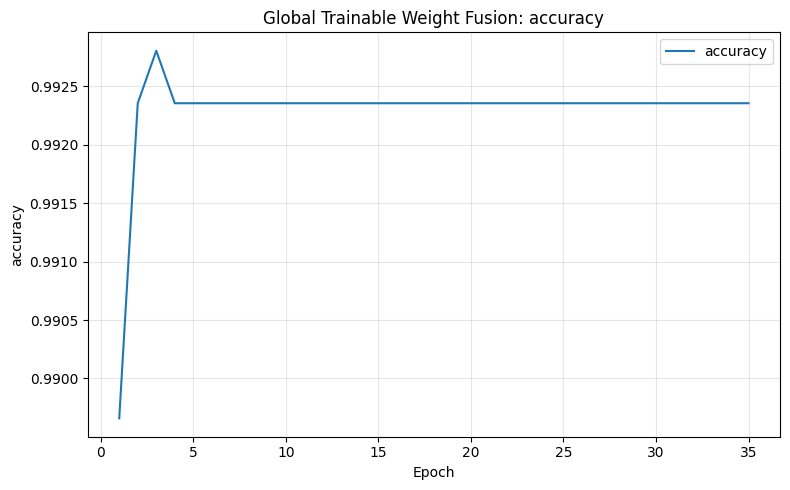

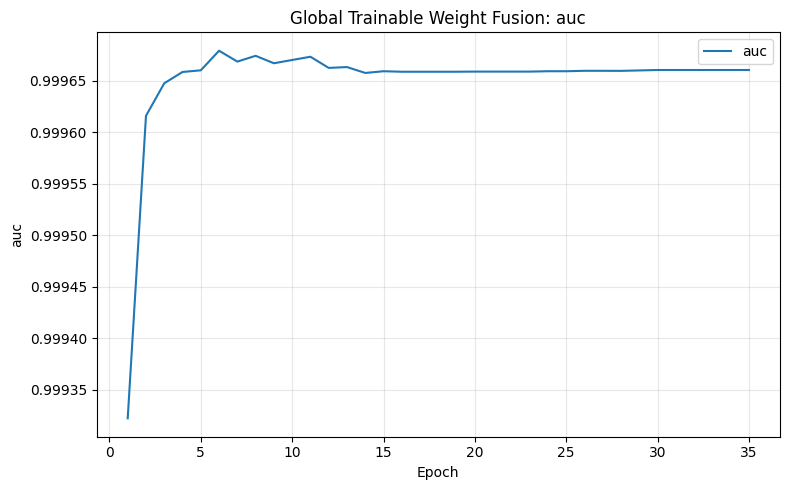

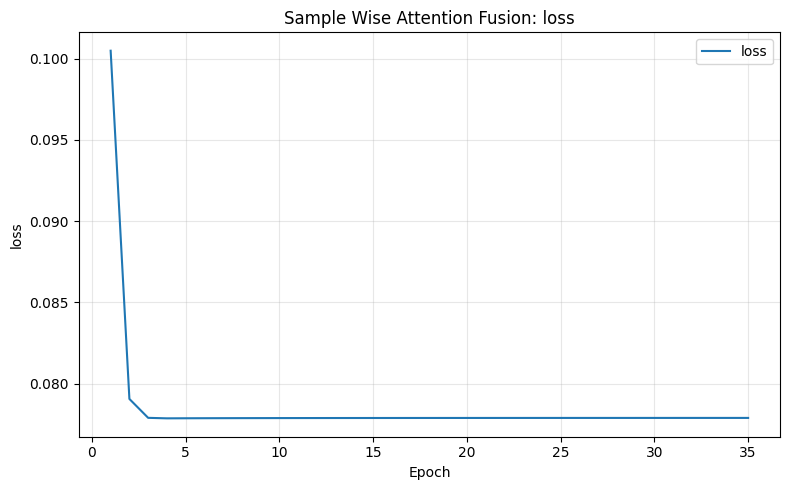

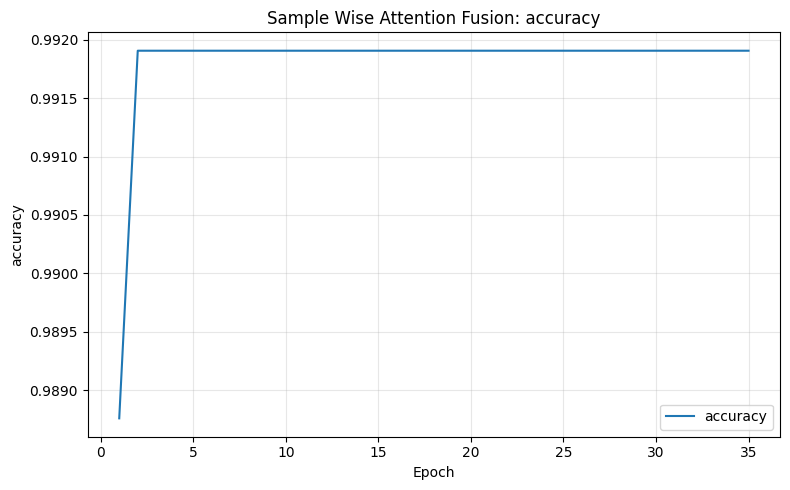

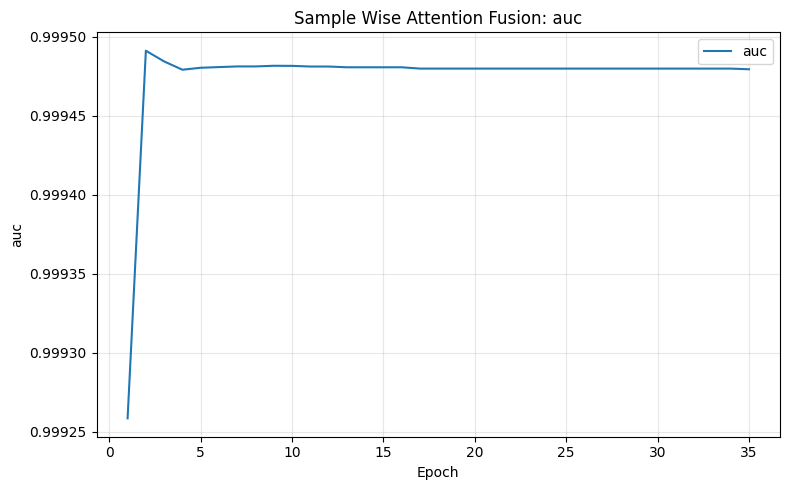

Grid-selected weights: [0.95 0.05 0.  ]
Global learned weights: [9.9952698e-01 2.4971506e-04 2.2324601e-04]
All late-fusion methods were fitted using development images only.


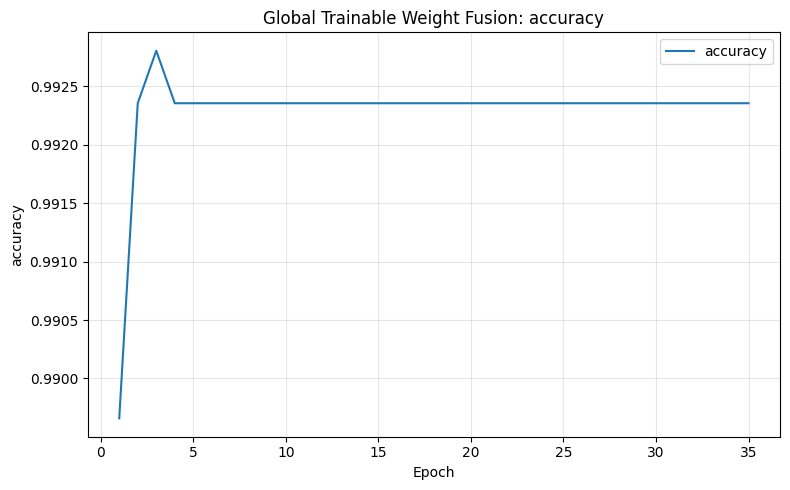

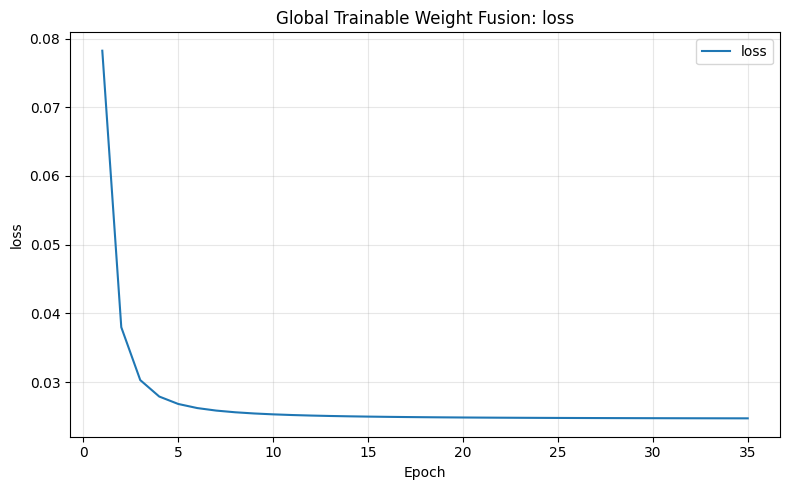

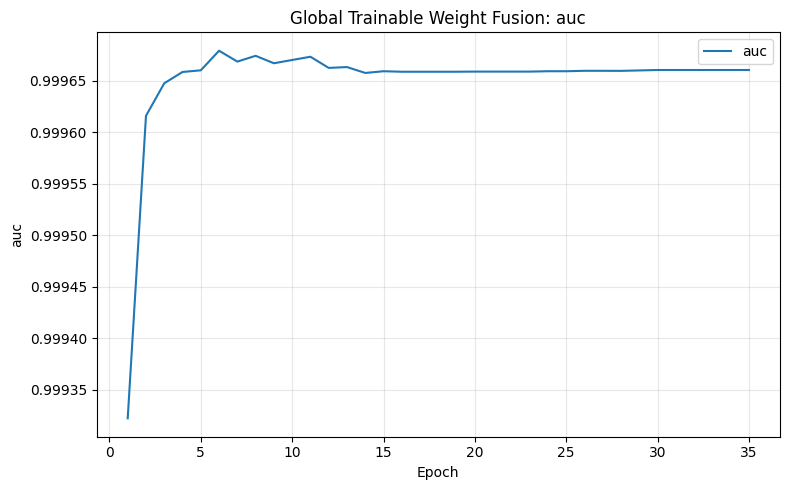

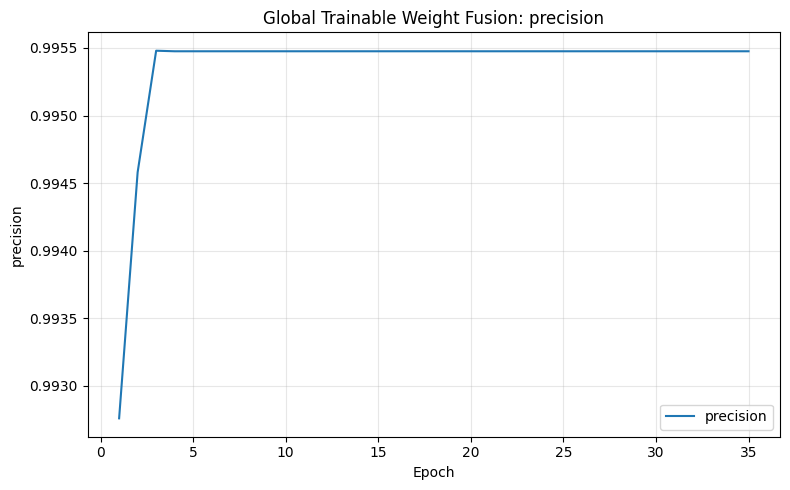

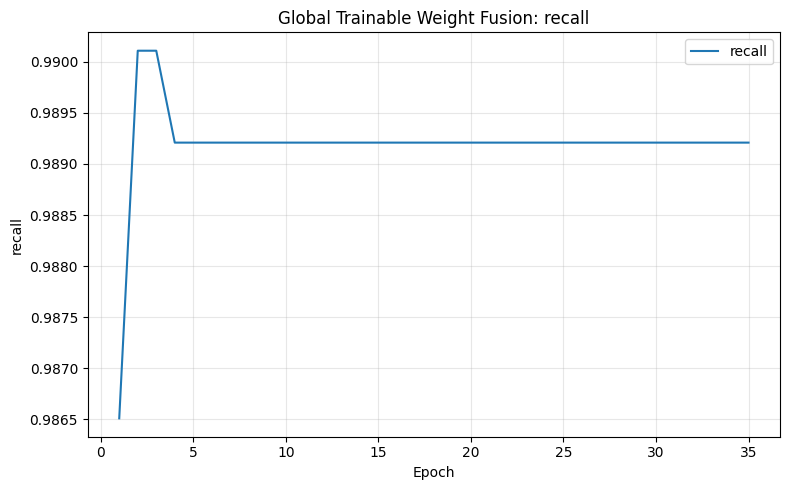

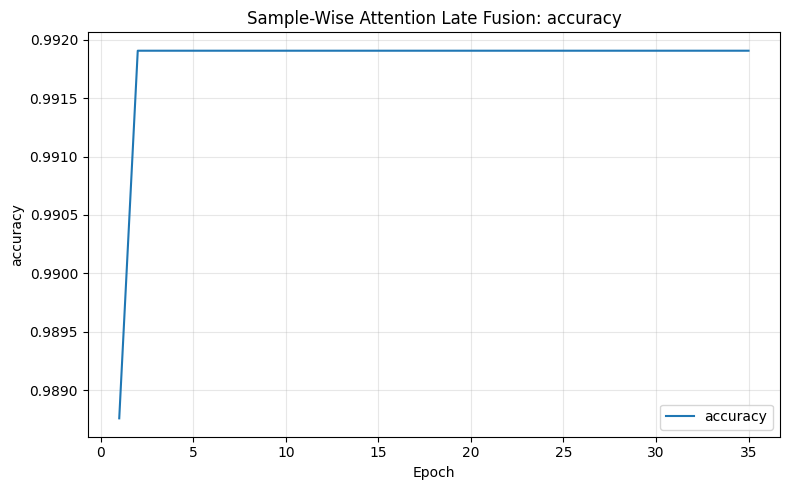

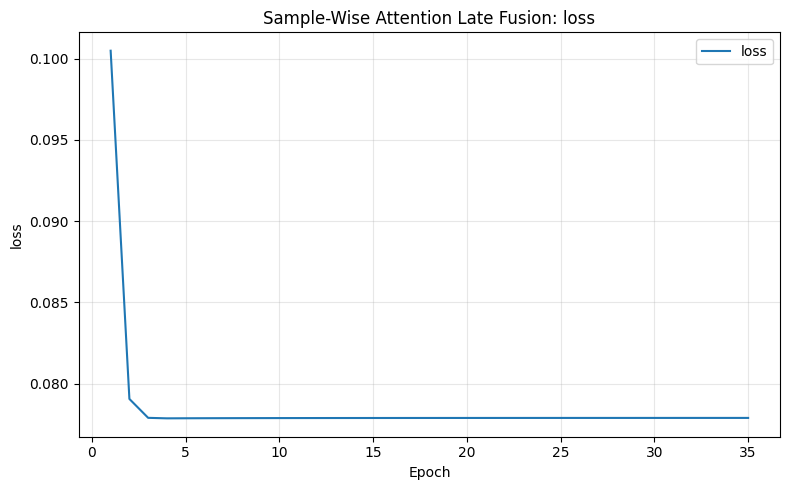

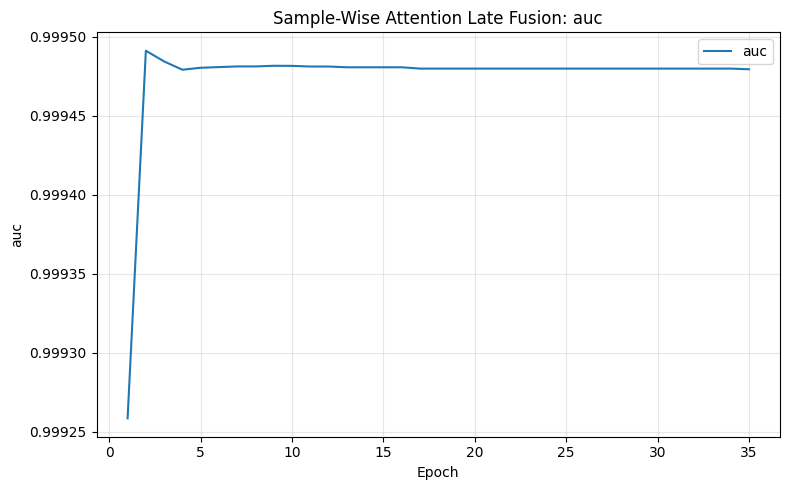

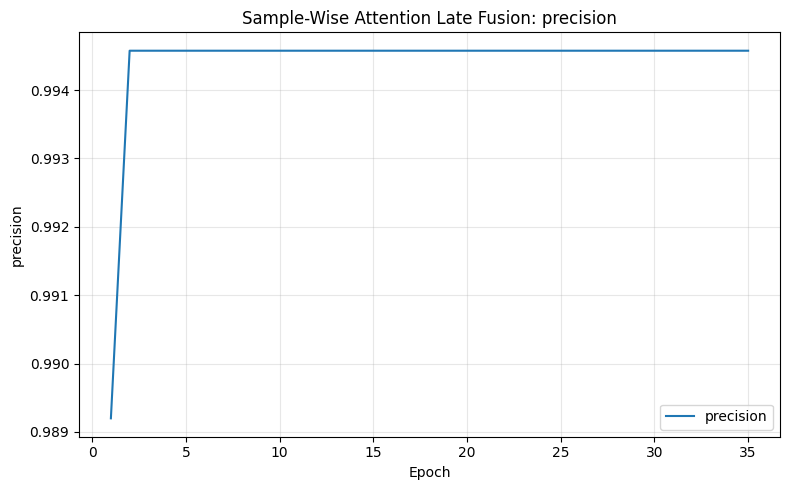

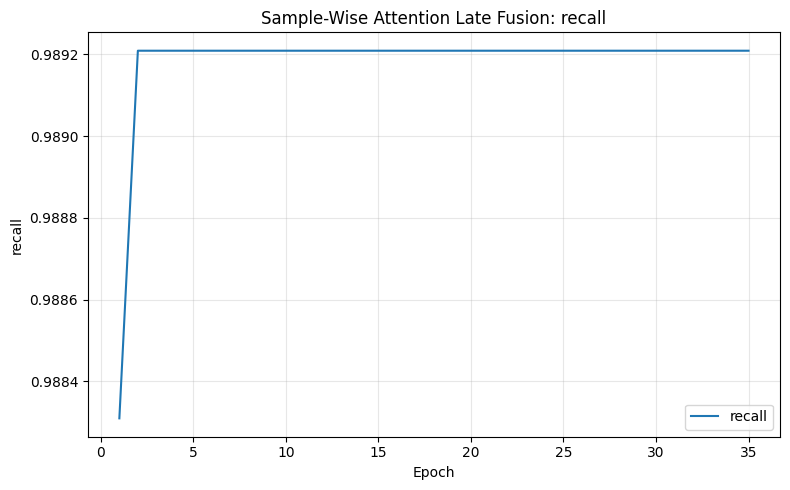

Global trainable weights and attention fusion completed 35 epochs.


In [25]:
PROBABILITY_COLUMNS = [
    "vgg16_probability",
    "densenet121_probability",
    "mobilenetv2_probability",
]


X_development = (
    development_table[
        PROBABILITY_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )
)

y_development = (
    development_table[
        "label"
    ].to_numpy(
        dtype=np.int32
    )
)

X_test_images = (
    test_table[
        PROBABILITY_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )
)

y_test_images = (
    test_table[
        "label"
    ].to_numpy(
        dtype=np.int32
    )
)


def safe_auc(y_true, y_prob):
    return (
        float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        )
        if len(
            np.unique(y_true)
        ) == 2
        else float("nan")
    )


def select_convex_weights(
    X,
    y,
    step=0.05,
):
    n = int(
        round(1 / step)
    )

    best = None

    for first in range(n + 1):
        for second in range(
            n - first + 1
        ):
            third = (
                n
                - first
                - second
            )

            weights = (
                np.array(
                    [
                        first,
                        second,
                        third,
                    ],
                    dtype=np.float32,
                )
                / n
            )

            probability = (
                X @ weights
            )

            prediction = (
                probability >= 0.5
            ).astype(np.int32)

            score = (
                safe_auc(
                    y,
                    probability,
                ),
                float(
                    f1_score(
                        y,
                        prediction,
                        zero_division=0,
                    )
                ),
                float(
                    accuracy_score(
                        y,
                        prediction,
                    )
                ),
            )

            if (
                best is None
                or score > best["score"]
            ):
                best = {
                    "weights": weights,
                    "score": score,
                }

    return best


grid_result = (
    select_convex_weights(
        X_development,
        y_development,
    )
)

GRID_WEIGHTS = (
    grid_result["weights"]
)


global_input = keras.Input(
    shape=(3,),
    name="base_probabilities",
)

global_output = GlobalTrainableFusion(
    3,
    name="global_trainable_fusion",
)(global_input)

global_model = keras.Model(
    global_input,
    global_output,
)

global_model.compile(
    optimizer=keras.optimizers.Adam(
        0.01
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

global_local_path = (
    LOCAL_FUSION_DIR
    / "global_trainable_fusion.keras"
)

global_drive_path = (
    FUSION_DIR
    / "global_trainable_fusion.keras"
)

if global_local_path.exists():
    global_local_path.unlink()

global_history = global_model.fit(
    X_development,
    y_development,
    epochs=GLOBAL_FUSION_EPOCHS,
    batch_size=min(
        16,
        len(X_development),
    ),
    shuffle=True,
    callbacks=[
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ModelCheckpoint(
            str(global_local_path),
            monitor="loss",
            mode="min",
            save_best_only=True,
            verbose=0,
        ),
    ],
    verbose=0,
)

if not global_local_path.exists():
    global_model.save(global_local_path)

global_model = load_model_safely(
    global_local_path
)

copy_file_with_retry(
    global_local_path,
    global_drive_path,
)

global_layer = global_model.get_layer(
    "global_trainable_fusion"
)

GLOBAL_WEIGHTS = tf.nn.softmax(
    global_layer.raw_weights
).numpy()


attention_input = keras.Input(
    shape=(3,),
    name="base_probabilities",
)

attention_weights = layers.Dense(
    3,
    activation="softmax",
    kernel_regularizer=(
        keras.regularizers.l2(
            0.02
        )
    ),
    bias_regularizer=(
        keras.regularizers.l2(
            0.02
        )
    ),
    name="attention_weights",
)(attention_input)

attention_output = (
    AttentionWeightedSum(
        name="attention_probability"
    )(
        [
            attention_input,
            attention_weights,
        ]
    )
)

attention_model = keras.Model(
    attention_input,
    attention_output,
)

attention_model.compile(
    optimizer=keras.optimizers.Adam(
        0.005
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

attention_local_path = (
    LOCAL_FUSION_DIR
    / "attention_fusion.keras"
)

attention_drive_path = (
    FUSION_DIR
    / "attention_fusion.keras"
)

if attention_local_path.exists():
    attention_local_path.unlink()

attention_history = (
    attention_model.fit(
        X_development,
        y_development,
        epochs=(
            ATTENTION_FUSION_EPOCHS
        ),
        batch_size=min(
            16,
            len(X_development),
        ),
        shuffle=True,
        callbacks=[
            keras.callbacks.TerminateOnNaN(),
            keras.callbacks.ModelCheckpoint(
                str(attention_local_path),
                monitor="loss",
                mode="min",
                save_best_only=True,
                verbose=0,
            ),
        ],
        verbose=0,
    )
)

attention_model = load_model_safely(
    attention_local_path
)


stacking_model = Pipeline(
    [
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "meta_classifier",
            LogisticRegression(
                C=0.10,
                class_weight="balanced",
                max_iter=3000,
                random_state=SEED,
            ),
        ),
    ]
)

stacking_model.fit(
    X_development,
    y_development,
)

stacking_local_path = (
    LOCAL_FUSION_DIR
    / "logistic_stacking.joblib"
)

stacking_drive_path = (
    FUSION_DIR
    / "logistic_stacking.joblib"
)

if stacking_local_path.exists():
    stacking_local_path.unlink()

joblib.dump(
    stacking_model,
    stacking_local_path,
)

copy_file_with_retry(
    stacking_local_path,
    stacking_drive_path,
)


test_method_probabilities = {
    "VGG16": (
        X_test_images[:, 0]
    ),
    "DenseNet121": (
        X_test_images[:, 1]
    ),
    "MobileNetV2": (
        X_test_images[:, 2]
    ),
    "Equal Average Late Fusion": (
        X_test_images.mean(
            axis=1
        )
    ),
    "Manual Weighted Late Fusion": (
        X_test_images
        @ MANUAL_WEIGHTS
    ),
    "Development Grid Weighted Late Fusion": (
        X_test_images
        @ GRID_WEIGHTS
    ),
    "Global Trainable Weight Fusion": (
        np.asarray(
            global_model.predict(
                X_test_images,
                verbose=0,
            )
        ).reshape(-1)
    ),
    "Sample Wise Attention Late Fusion": (
        np.asarray(
            attention_model.predict(
                X_test_images,
                verbose=0,
            )
        ).reshape(-1)
    ),
    "Logistic Regression Stacking": (
        stacking_model.predict_proba(
            X_test_images
        )[:, 1]
    ),
}


attention_extractor = keras.Model(
    attention_model.input,
    attention_model.get_layer(
        "attention_weights"
    ).output,
)

mean_attention_weights = (
    attention_extractor.predict(
        X_development,
        verbose=0,
    ).mean(axis=0)
)


weights_table = pd.DataFrame(
    {
        "Model": BASE_MODEL_NAMES,
        "Manual Weight": (
            MANUAL_WEIGHTS
        ),
        "Development Grid Weight": (
            GRID_WEIGHTS
        ),
        "Global Learned Weight": (
            GLOBAL_WEIGHTS
        ),
        "Mean Development Attention Weight": (
            mean_attention_weights
        ),
    }
)

weights_table.to_csv(
    TABLES_DIR
    / "late_fusion_weights.csv",
    index=False,
)


def plot_fusion_history(
    history,
    fusion_name,
    prefix,
):
    history_dictionary = (
        history.history
        if hasattr(
            history,
            "history",
        )
        else history
    )

    for metric in [
        "loss",
        "accuracy",
        "auc",
    ]:
        values = history_dictionary.get(
            metric,
            [],
        )

        if not values:
            continue

        epochs = np.arange(
            1,
            len(values) + 1,
        )

        figure, axis = plt.subplots(
            figsize=(8, 5)
        )

        axis.plot(
            epochs,
            values,
            label=metric,
        )

        axis.set_title(
            f"{fusion_name}: {metric}"
        )
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric)
        axis.grid(alpha=0.3)
        axis.legend()
        figure.tight_layout()

        output = (
            GRAPHS_DIR
            / f"{prefix}_{metric}.png"
        )

        figure.savefig(
            output,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(figure)


plot_fusion_history(
    global_history,
    "Global Trainable Weight Fusion",
    "global_trainable_fusion",
)

plot_fusion_history(
    attention_history,
    "Sample Wise Attention Fusion",
    "sample_wise_attention_fusion",
)


print(
    "Grid-selected weights:",
    GRID_WEIGHTS,
)
print(
    "Global learned weights:",
    GLOBAL_WEIGHTS,
)
print(
    "All late-fusion methods were fitted "
    "using development images only."
)


def plot_fusion_training_history(
    history,
    fusion_name,
    filename_prefix,
):
    history_dictionary = (
        history.history
        if hasattr(history, "history")
        else history
    )

    for metric in [
        "accuracy",
        "loss",
        "auc",
        "precision",
        "recall",
    ]:
        values = history_dictionary.get(
            metric,
            [],
        )
        if not values:
            continue

        epochs = np.arange(
            1,
            len(values) + 1,
        )

        figure, axis = plt.subplots(
            figsize=(8, 5)
        )
        axis.plot(
            epochs,
            values,
            label=metric,
        )
        axis.set_title(
            f"{fusion_name}: {metric}"
        )
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric)
        axis.grid(alpha=0.3)
        axis.legend()
        figure.tight_layout()

        output_path = (
            GRAPHS_DIR
            / f"{filename_prefix}_{metric}.png"
        )
        figure.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(figure)


plot_fusion_training_history(
    global_history,
    "Global Trainable Weight Fusion",
    "global_trainable_weight_fusion",
)

plot_fusion_training_history(
    attention_history,
    "Sample-Wise Attention Late Fusion",
    "sample_wise_attention_late_fusion",
)

global_history_table = pd.DataFrame(
    global_history.history
)
global_history_table.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(global_history_table) + 1,
    ),
)
global_history_table.to_csv(
    HISTORY_DIR
    / "global_trainable_weight_fusion_history.csv",
    index=False,
)

attention_history_table = pd.DataFrame(
    attention_history.history
)
attention_history_table.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(attention_history_table) + 1,
    ),
)
attention_history_table.to_csv(
    HISTORY_DIR
    / "sample_wise_attention_late_fusion_history.csv",
    index=False,
)

if len(global_history.history.get("loss", [])) != GLOBAL_FUSION_EPOCHS:
    raise RuntimeError(
        "Global trainable-weight fusion did not complete 35 epochs."
    )

if len(attention_history.history.get("loss", [])) != ATTENTION_FUSION_EPOCHS:
    raise RuntimeError(
        "Attention late fusion did not complete 35 epochs."
    )

print(
    "Global trainable weights and attention fusion "
    "completed 35 epochs."
)


## Evaluate every method at image level

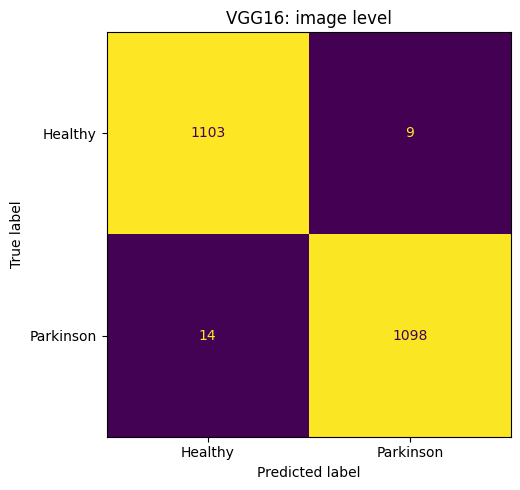

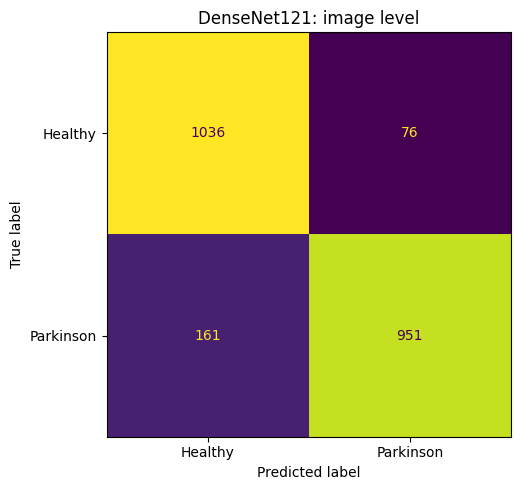

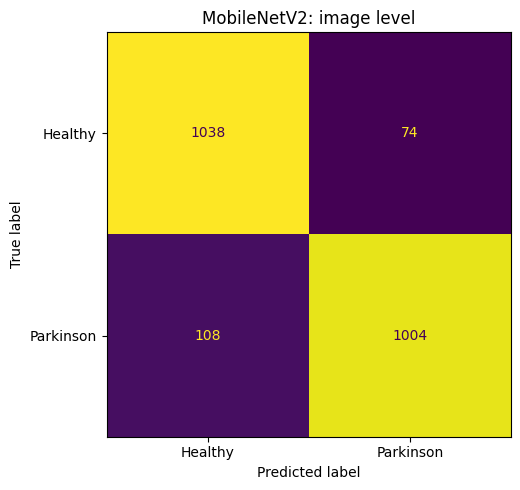

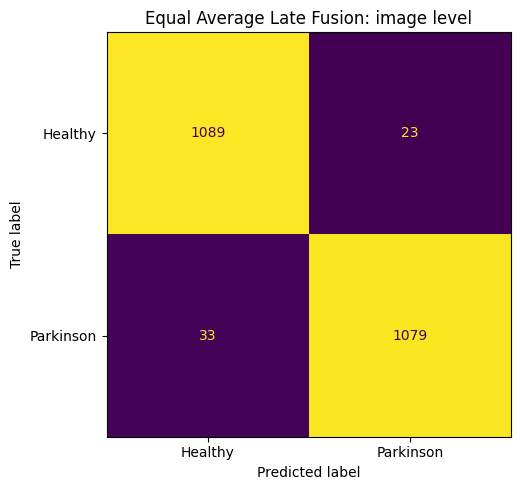

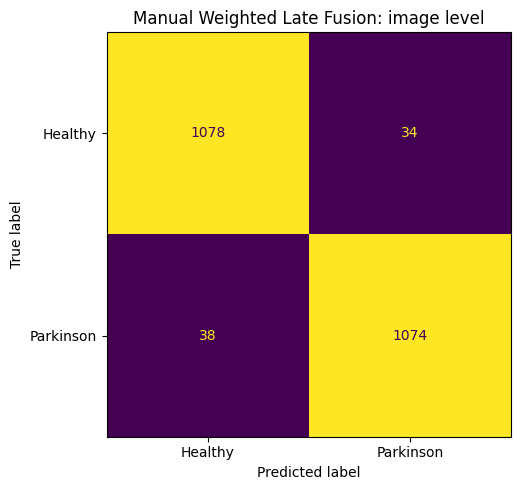

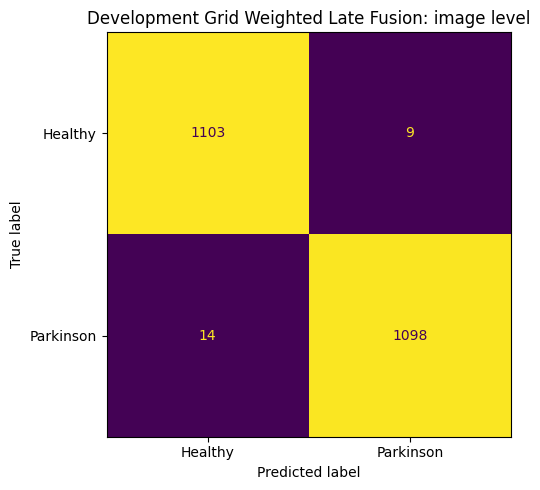

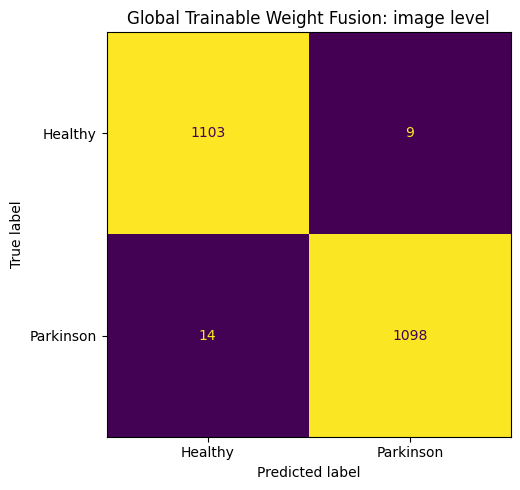

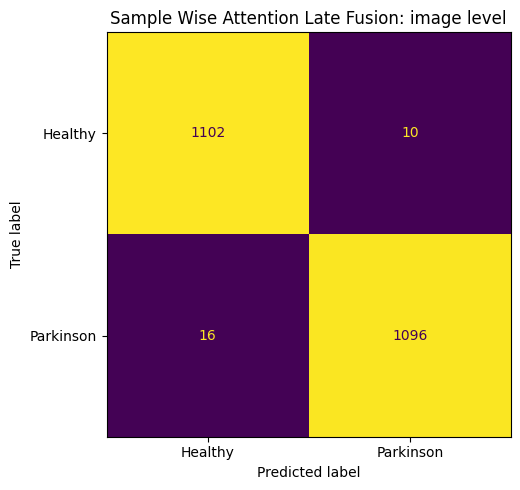

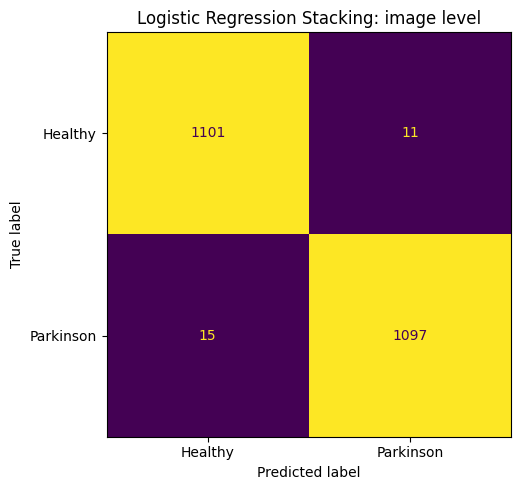

,Method,Evaluation Level,Test Images,Accuracy,Precision,Recall,Specificity,F1,ROC AUC,Threshold,Split Fingerprint
0,Development Grid Weighted Late Fusion,Image,2224,0.989658,0.991870,0.987410,0.991906,0.989635,0.999494,0.5,fcc9976abdc6803bf00c
1,Sample Wise Attention Late Fusion,Image,2224,0.988309,0.990958,0.985612,0.991007,0.988278,0.999471,0.5,fcc9976abdc6803bf00c
2,Logistic Regression Stacking,Image,2224,0.988309,0.990072,0.986511,0.990108,0.988288,0.999406,0.5,fcc9976abdc6803bf00c
3,Global Trainable Weight Fusion,Image,2224,0.989658,0.991870,0.987410,0.991906,0.989635,0.999393,0.5,fcc9976abdc6803bf00c
4,VGG16,Image,2224,0.989658,0.991870,0.987410,0.991906,0.989635,0.999380,0.5,fcc9976abdc6803bf00c
5,Equal Average Late Fusion,Image,2224,0.974820,0.979129,0.970324,0.979317,0.974706,0.998012,0.5,fcc9976abdc6803bf00c
6,Manual Weighted Late Fusion,Image,2224,0.967626,0.969314,0.965827,0.969424,0.967568,0.995864,0.5,fcc9976abdc6803bf00c
7,MobileNetV2,Image,2224,0.918165,0.931354,0.902878,0.933453,0.916895,0.977962,0.5,fcc9976abdc6803bf00c
8,DenseNet121,Image,2224,0.893435,0.925998,0.855216,0.931655,0.889201,0.970212,0.5,fcc9976abdc6803bf00c


Best image-level method: Development Grid Weighted Late Fusion


In [26]:
result_rows = []
artifacts = {}


def metrics(y_true, y_prob):
    y_true = np.asarray(
        y_true,
        dtype=np.int32,
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise ValueError(
            "Length mismatch."
        )

    if (
        not np.all(
            np.isfinite(y_prob)
        )
        or np.any(y_prob < 0)
        or np.any(y_prob > 1)
    ):
        raise ValueError(
            "Invalid probabilities."
        )

    y_pred = (
        y_prob >= 0.5
    ).astype(np.int32)

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "specificity": float(
            specificity
        ),
        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "auc": safe_auc(
            y_true,
            y_prob,
        ),
        "prediction": y_pred,
        "confusion_matrix": matrix,
    }


def save_verified_roc_npz(
    path,
    method_name,
    image_paths,
    y_true,
    y_prob,
    y_pred,
):
    y_true = np.asarray(
        y_true,
        dtype=np.int32,
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=np.int32,
    ).reshape(-1)

    image_paths = np.asarray(
        image_paths,
        dtype="U",
    ).reshape(-1)

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob,
    )

    auc_value = float(
        roc_auc_score(
            y_true,
            y_prob,
        )
    )

    np.savez_compressed(
        path,
        image_paths=image_paths,
        y_true=y_true,
        y_prob=y_prob,
        y_probability=y_prob,
        y_pred=y_pred,
        fpr=np.asarray(
            fpr,
            dtype=np.float64,
        ),
        tpr=np.asarray(
            tpr,
            dtype=np.float64,
        ),
        thresholds=np.asarray(
            thresholds,
            dtype=np.float64,
        ),
        auc=np.asarray(
            auc_value,
            dtype=np.float64,
        ),
        method_name=np.asarray(
            method_name
        ),
        evaluation_level=np.asarray(
            "image_level"
        ),
        split_fingerprint=np.asarray(
            SPLIT_FINGERPRINT
        ),
        threshold=np.asarray(
            0.5,
            dtype=np.float64,
        ),
        positive_class=np.asarray(
            "Parkinson"
        ),
        negative_class=np.asarray(
            "Healthy"
        ),
    )

    with np.load(
        path,
        allow_pickle=False,
    ) as check:
        required_keys = {
            "image_paths",
            "y_true",
            "y_prob",
            "y_pred",
            "fpr",
            "tpr",
            "thresholds",
            "auc",
            "method_name",
            "evaluation_level",
            "split_fingerprint",
        }

        missing_keys = (
            required_keys
            - set(check.files)
        )

        if missing_keys:
            raise RuntimeError(
                "ROC NPZ is missing keys: "
                f"{sorted(missing_keys)}"
            )

        if (
            check["y_true"].shape
            != check["y_prob"].shape
        ):
            raise RuntimeError(
                "Incorrect ROC NPZ shapes."
            )

    return str(path)


def save_confusion(
    matrix,
    title,
    path,
):
    figure, axis = plt.subplots(
        figsize=(6, 5)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Healthy",
            "Parkinson",
        ],
    ).plot(
        ax=axis,
        values_format="d",
        colorbar=False,
    )

    axis.set_title(title)
    figure.tight_layout()

    figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


def evaluate_method(
    method_name,
    image_probability,
):
    safe_name = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        method_name,
    ).strip("_").lower()

    image_probability = np.asarray(
        image_probability,
        dtype=np.float32,
    ).reshape(-1)

    image_result = metrics(
        y_test_images,
        image_probability,
    )

    image_prediction = (
        image_result.pop(
            "prediction"
        )
    )

    matrix = image_result.pop(
        "confusion_matrix"
    )

    prediction_table = (
        test_table[
            [
                "filepath",
                "filename",
                "patient_id",
                "slice_index",
                "label",
                "class_name",
            ]
        ].copy()
    )

    prediction_table[
        "probability"
    ] = image_probability

    prediction_table[
        "predicted_label"
    ] = image_prediction

    prediction_table["correct"] = (
        prediction_table[
            "label"
        ].to_numpy()
        == image_prediction
    )

    prediction_path = (
        PREDICTIONS_DIR
        / f"{safe_name}_image_predictions.csv"
    )

    prediction_table.to_csv(
        prediction_path,
        index=False,
    )

    image_npz = save_verified_roc_npz(
        ROC_DIR
        / f"{safe_name}_image_roc_data.npz",
        method_name=method_name,
        image_paths=prediction_table[
            "filepath"
        ],
        y_true=y_test_images,
        y_prob=image_probability,
        y_pred=image_prediction,
    )

    report_path = (
        REPORTS_DIR
        / f"{safe_name}_image_report.txt"
    )

    report_path.write_text(
        "IMAGE-LEVEL REPORT\n"
        "==================\n"
        + classification_report(
            y_test_images,
            image_prediction,
            target_names=[
                "Healthy",
                "Parkinson",
            ],
            digits=4,
            zero_division=0,
        ),
        encoding="utf-8",
    )

    confusion_path = (
        CONFUSION_DIR
        / f"{safe_name}_image_confusion.png"
    )

    save_confusion(
        matrix,
        f"{method_name}: image level",
        confusion_path,
    )

    row = {
        "Method": method_name,
        "Evaluation Level": (
            "Image"
        ),
        "Test Images": int(
            len(y_test_images)
        ),
        "Accuracy": (
            image_result[
                "accuracy"
            ]
        ),
        "Precision": (
            image_result[
                "precision"
            ]
        ),
        "Recall": (
            image_result[
                "recall"
            ]
        ),
        "Specificity": (
            image_result[
                "specificity"
            ]
        ),
        "F1": image_result["f1"],
        "ROC AUC": (
            image_result["auc"]
        ),
        "Threshold": 0.5,
        "Split Fingerprint": (
            SPLIT_FINGERPRINT
        ),
    }

    result_rows.append(row)

    artifacts[method_name] = {
        "safe_name": safe_name,
        "image_npz": image_npz,
        "image_predictions": (
            prediction_table
        ),
        "prediction_path": str(
            prediction_path
        ),
        "report_path": str(
            report_path
        ),
        "confusion_path": str(
            confusion_path
        ),
        "result": row,
    }


for method_name, probability in (
    test_method_probabilities.items()
):
    evaluate_method(
        method_name,
        probability,
    )


results_df = (
    pd.DataFrame(result_rows)
    .sort_values(
        [
            "ROC AUC",
            "F1",
            "Accuracy",
        ],
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)


comparison_csv = (
    TABLES_DIR
    / "image_level_late_fusion_comparison.csv"
)

comparison_xlsx = (
    TABLES_DIR
    / "image_level_late_fusion_comparison.xlsx"
)

results_df.to_csv(
    comparison_csv,
    index=False,
)

results_df.to_excel(
    comparison_xlsx,
    index=False,
)

BEST_METHOD = str(
    results_df.loc[
        0,
        "Method",
    ]
)

display(results_df)

print(
    "Best image-level method:",
    BEST_METHOD,
)

## Combined image-level ROC graph and standard ROC NPZ aliases

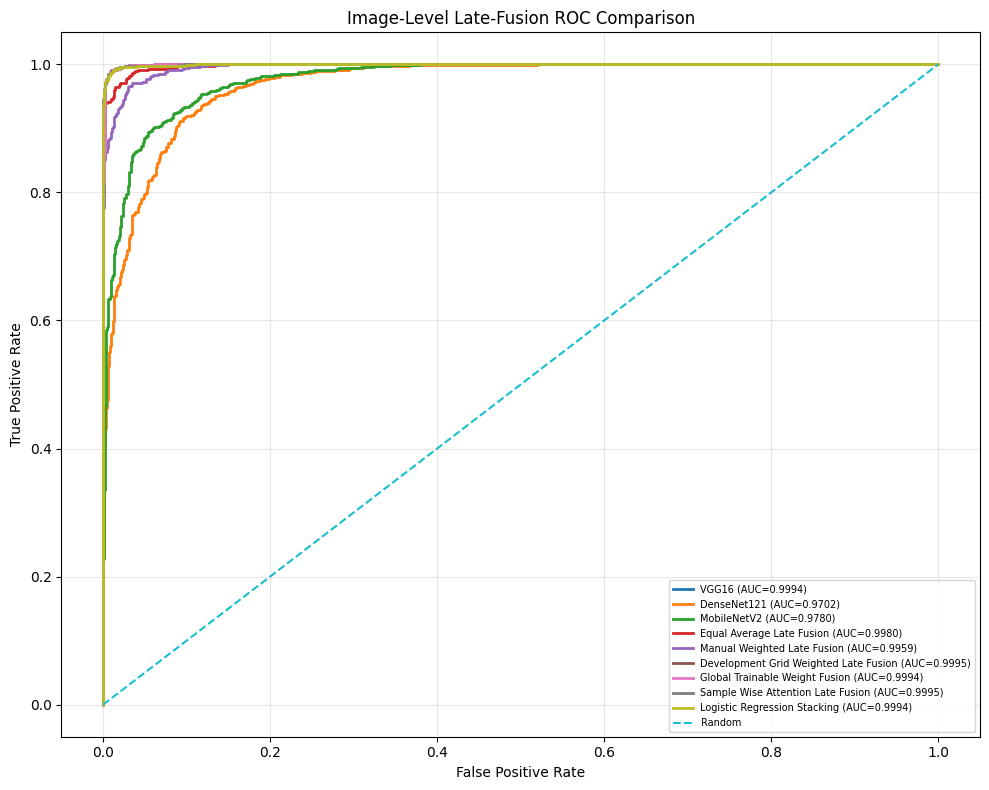

Combined ROC NPZ keys: ['image_paths', 'y_true', 'split_fingerprint', 'evaluation_level', 'vgg16_y_prob', 'vgg16_fpr', 'vgg16_tpr', 'vgg16_thresholds', 'vgg16_auc', 'densenet121_y_prob', 'densenet121_fpr', 'densenet121_tpr', 'densenet121_thresholds', 'densenet121_auc', 'mobilenetv2_y_prob', 'mobilenetv2_fpr', 'mobilenetv2_tpr', 'mobilenetv2_thresholds', 'mobilenetv2_auc', 'equal_average_late_fusion_y_prob', 'equal_average_late_fusion_fpr', 'equal_average_late_fusion_tpr', 'equal_average_late_fusion_thresholds', 'equal_average_late_fusion_auc', 'manual_weighted_late_fusion_y_prob', 'manual_weighted_late_fusion_fpr', 'manual_weighted_late_fusion_tpr', 'manual_weighted_late_fusion_thresholds', 'manual_weighted_late_fusion_auc', 'development_grid_weighted_late_fusion_y_prob', 'development_grid_weighted_late_fusion_fpr', 'development_grid_weighted_late_fusion_tpr', 'development_grid_weighted_late_fusion_thresholds', 'development_grid_weighted_late_fusion_auc', 'global_trainable_weight_fusio

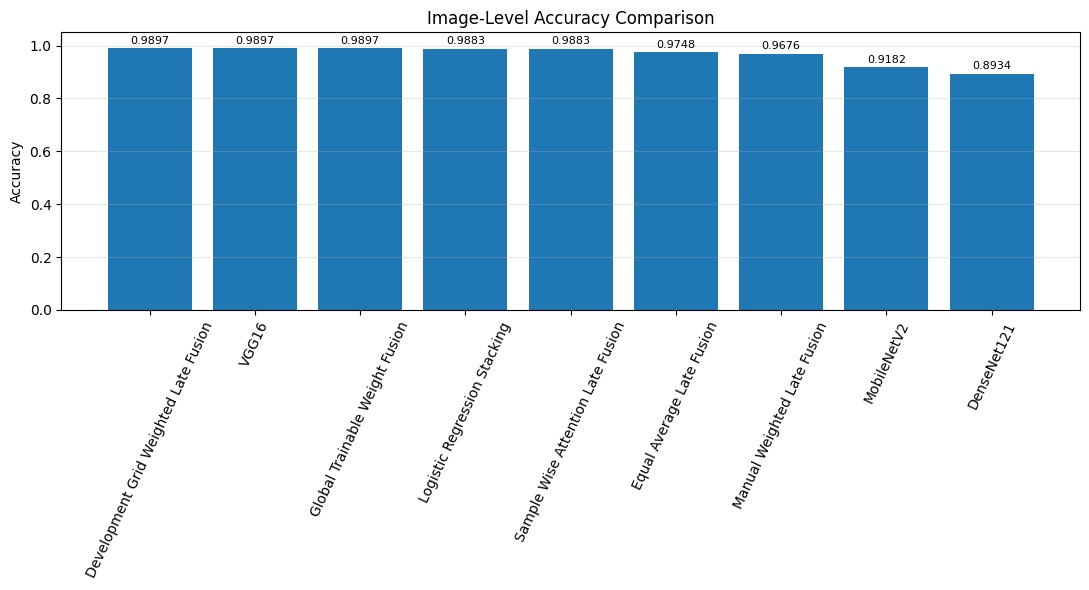

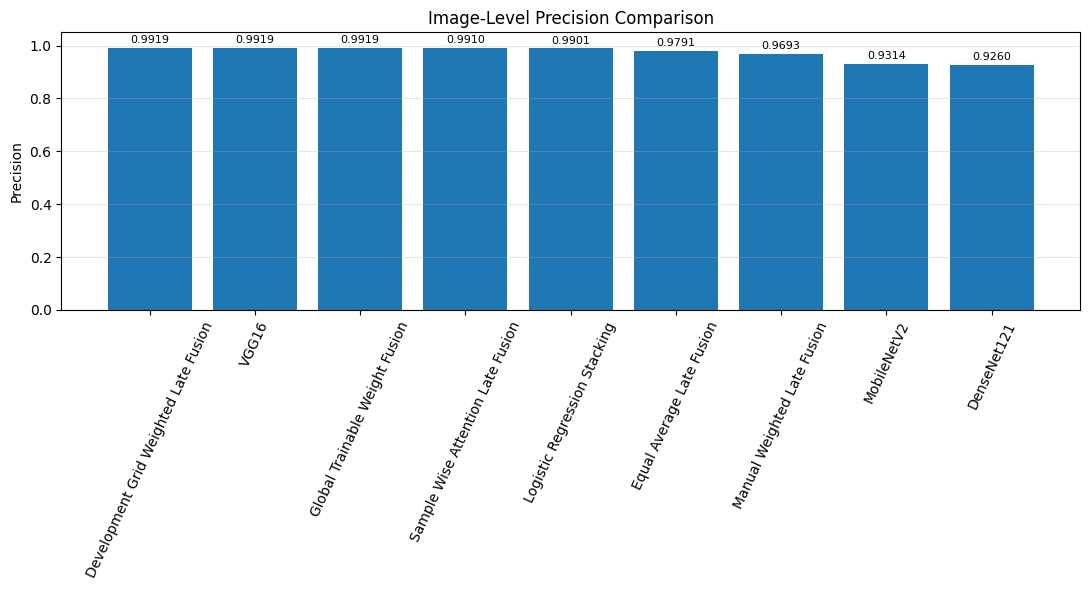

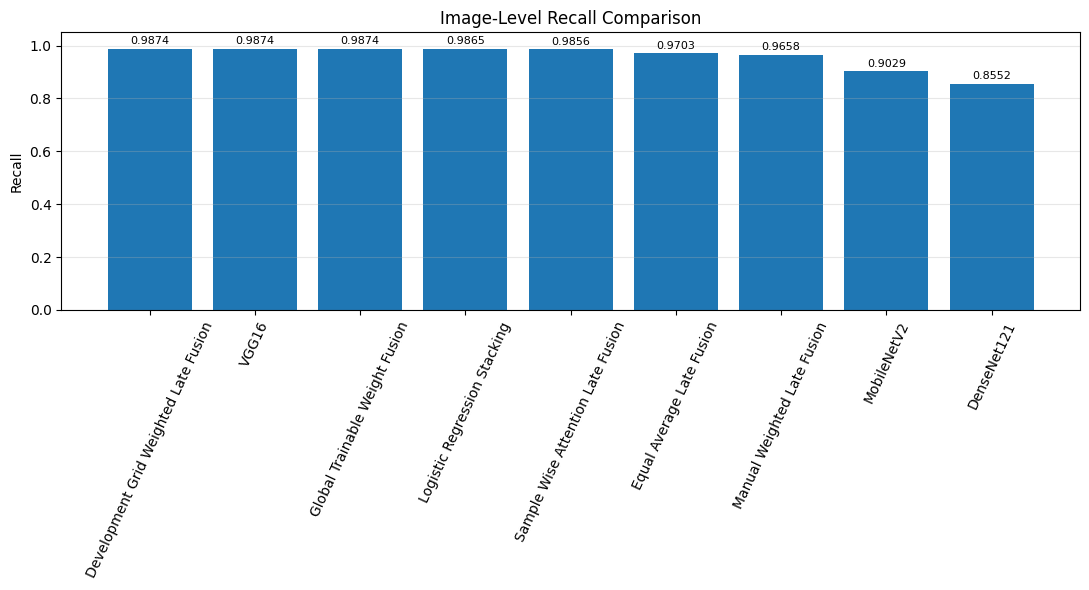

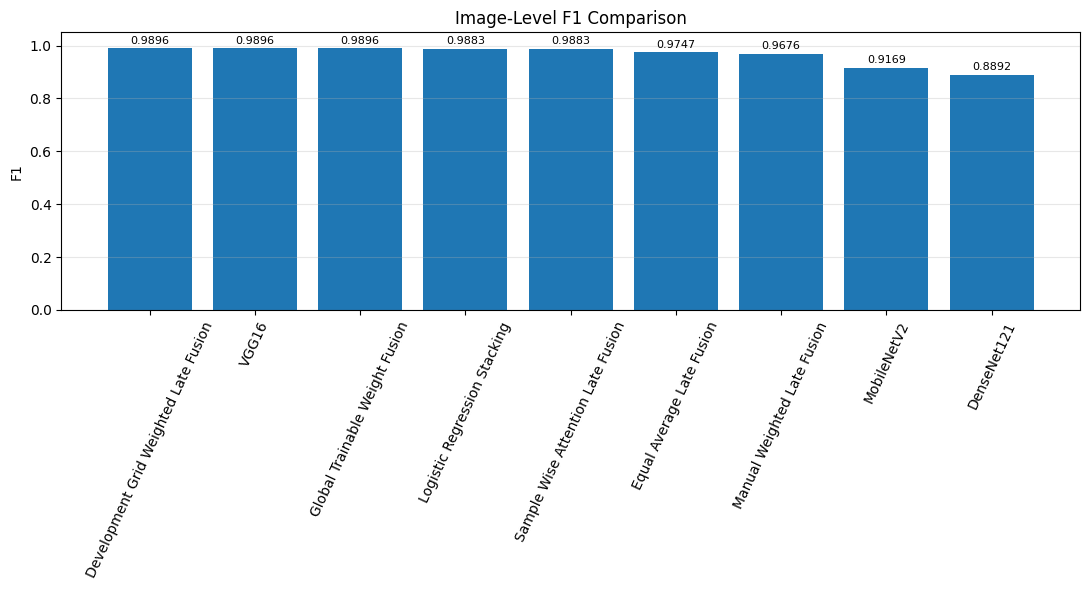

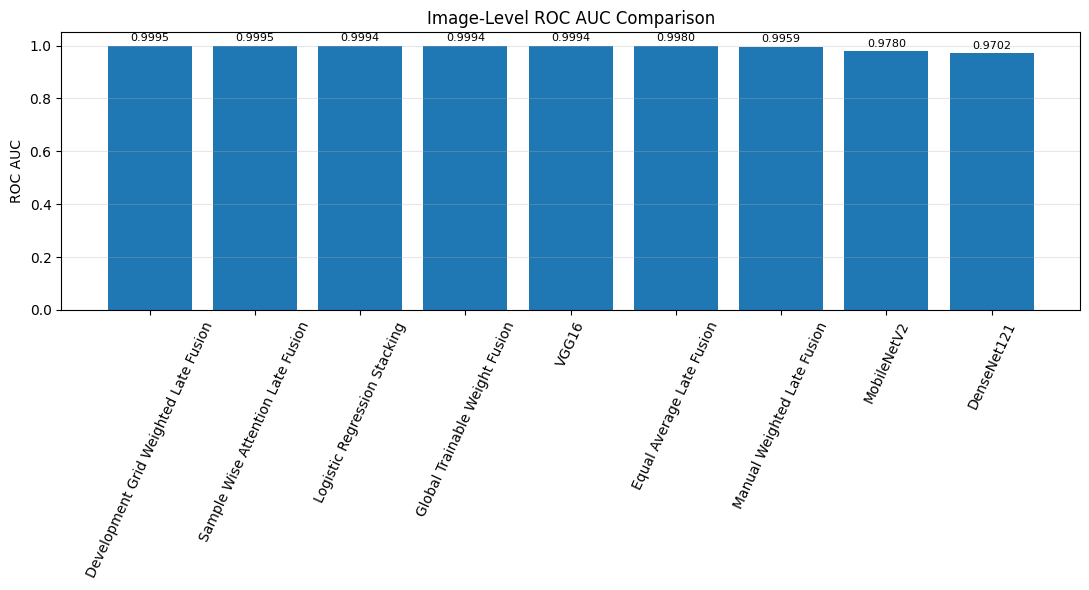

Best image ROC NPZ: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/roc_npz/best_late_fusion_image_roc_data.npz
Combined image ROC NPZ: /content/drive/MyDrive/New_image_level_updated_with_stacking/Updated_image_level_late_fusion_data_save_here/roc_npz/all_late_fusion_image_roc_data.npz


In [27]:
def plot_image_level_roc():
    figure, axis = plt.subplots(
        figsize=(10, 8)
    )

    combined_npz_data = {
        "image_paths": np.asarray(
            test_table["filepath"],
            dtype="U",
        ),
        "y_true": np.asarray(
            y_test_images,
            dtype=np.int32,
        ),
        "split_fingerprint": np.asarray(
            SPLIT_FINGERPRINT
        ),
        "evaluation_level": np.asarray(
            "image_level"
        ),
    }

    for method_name, artifact in (
        artifacts.items()
    ):
        path = artifact["image_npz"]

        with np.load(
            path,
            allow_pickle=False,
        ) as data:
            y_true = data["y_true"]
            y_prob = data["y_prob"]
            fpr = data["fpr"]
            tpr = data["tpr"]
            thresholds = data[
                "thresholds"
            ]
            auc_value = float(
                data["auc"]
            )

        axis.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"{method_name} "
                f"(AUC={auc_value:.4f})"
            ),
        )

        safe_name = artifact[
            "safe_name"
        ]

        combined_npz_data[
            f"{safe_name}_y_prob"
        ] = np.asarray(
            y_prob,
            dtype=np.float64,
        )

        combined_npz_data[
            f"{safe_name}_fpr"
        ] = np.asarray(
            fpr,
            dtype=np.float64,
        )

        combined_npz_data[
            f"{safe_name}_tpr"
        ] = np.asarray(
            tpr,
            dtype=np.float64,
        )

        combined_npz_data[
            f"{safe_name}_thresholds"
        ] = np.asarray(
            thresholds,
            dtype=np.float64,
        )

        combined_npz_data[
            f"{safe_name}_auc"
        ] = np.asarray(
            auc_value,
            dtype=np.float64,
        )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random",
    )

    axis.set_xlabel(
        "False Positive Rate"
    )
    axis.set_ylabel(
        "True Positive Rate"
    )
    axis.set_title(
        "Image-Level Late-Fusion "
        "ROC Comparison"
    )
    axis.grid(alpha=0.3)
    axis.legend(
        loc="lower right",
        fontsize=7,
    )
    figure.tight_layout()

    output = (
        GRAPHS_DIR
        / "image_level_roc_comparison.png"
    )

    figure.savefig(
        output,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    combined_npz_path = (
        ROC_DIR
        / "all_late_fusion_image_roc_data.npz"
    )

    np.savez_compressed(
        combined_npz_path,
        **combined_npz_data,
    )

    with np.load(
        combined_npz_path,
        allow_pickle=False,
    ) as verification:
        print(
            "Combined ROC NPZ keys:",
            verification.files,
        )

    return (
        output,
        combined_npz_path,
    )


(
    IMAGE_ROC_GRAPH,
    COMBINED_IMAGE_ROC_NPZ,
) = plot_image_level_roc()


best_artifact = artifacts[
    BEST_METHOD
]

with np.load(
    best_artifact["image_npz"],
    allow_pickle=False,
) as data:
    BEST_IMAGE_ALIAS = (
        ROC_DIR
        / "best_late_fusion_image_roc_data.npz"
    )

    np.savez_compressed(
        BEST_IMAGE_ALIAS,
        image_paths=data[
            "image_paths"
        ],
        y_true=data["y_true"],
        y_prob=data["y_prob"],
        y_probability=data[
            "y_probability"
        ],
        y_pred=data["y_pred"],
        fpr=data["fpr"],
        tpr=data["tpr"],
        thresholds=data[
            "thresholds"
        ],
        auc=data["auc"],
        method_name=data[
            "method_name"
        ],
        evaluation_level=data[
            "evaluation_level"
        ],
        split_fingerprint=data[
            "split_fingerprint"
        ],
        threshold=data[
            "threshold"
        ],
        positive_class=data[
            "positive_class"
        ],
        negative_class=data[
            "negative_class"
        ],
    )


for metric, filename in [
    (
        "Accuracy",
        "image_level_accuracy_comparison.png",
    ),
    (
        "Precision",
        "image_level_precision_comparison.png",
    ),
    (
        "Recall",
        "image_level_recall_comparison.png",
    ),
    (
        "F1",
        "image_level_f1_comparison.png",
    ),
    (
        "ROC AUC",
        "image_level_auc_comparison.png",
    ),
]:
    ordered = results_df.sort_values(
        metric,
        ascending=False,
    )

    figure, axis = plt.subplots(
        figsize=(11, 6)
    )

    bars = axis.bar(
        ordered["Method"],
        ordered[metric],
    )

    axis.set_title(
        f"Image-Level {metric} Comparison"
    )
    axis.set_ylabel(metric)
    axis.set_ylim(0, 1.05)
    axis.tick_params(
        axis="x",
        rotation=65,
    )
    axis.grid(
        axis="y",
        alpha=0.3,
    )

    for bar in bars:
        value = bar.get_height()

        axis.text(
            (
                bar.get_x()
                + bar.get_width() / 2
            ),
            min(
                value + 0.01,
                1.03,
            ),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    figure.tight_layout()

    figure.savefig(
        GRAPHS_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


print(
    "Best image ROC NPZ:",
    BEST_IMAGE_ALIAS,
)
print(
    "Combined image ROC NPZ:",
    COMBINED_IMAGE_ROC_NPZ,
)

## Validated base-model and weighted-ensemble Grad-CAM for image-level test examples

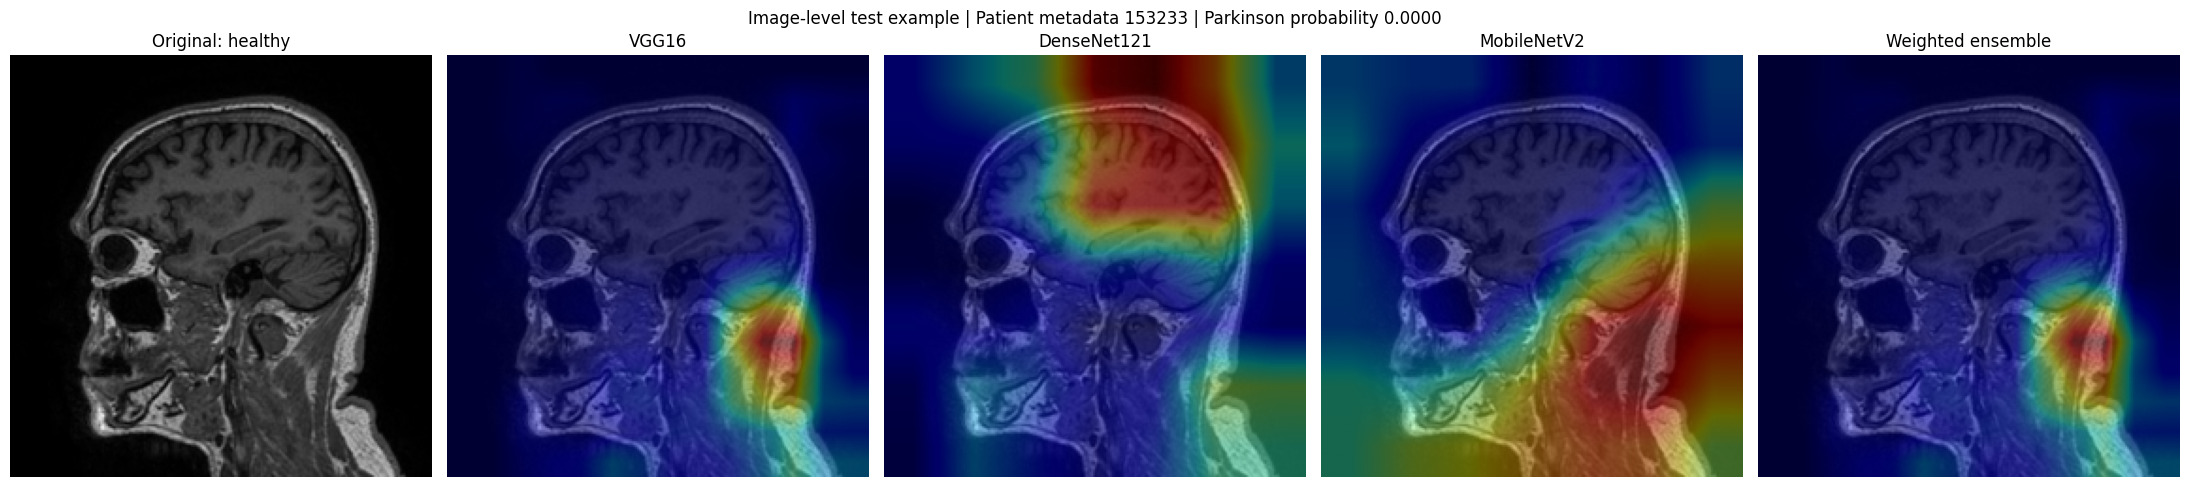

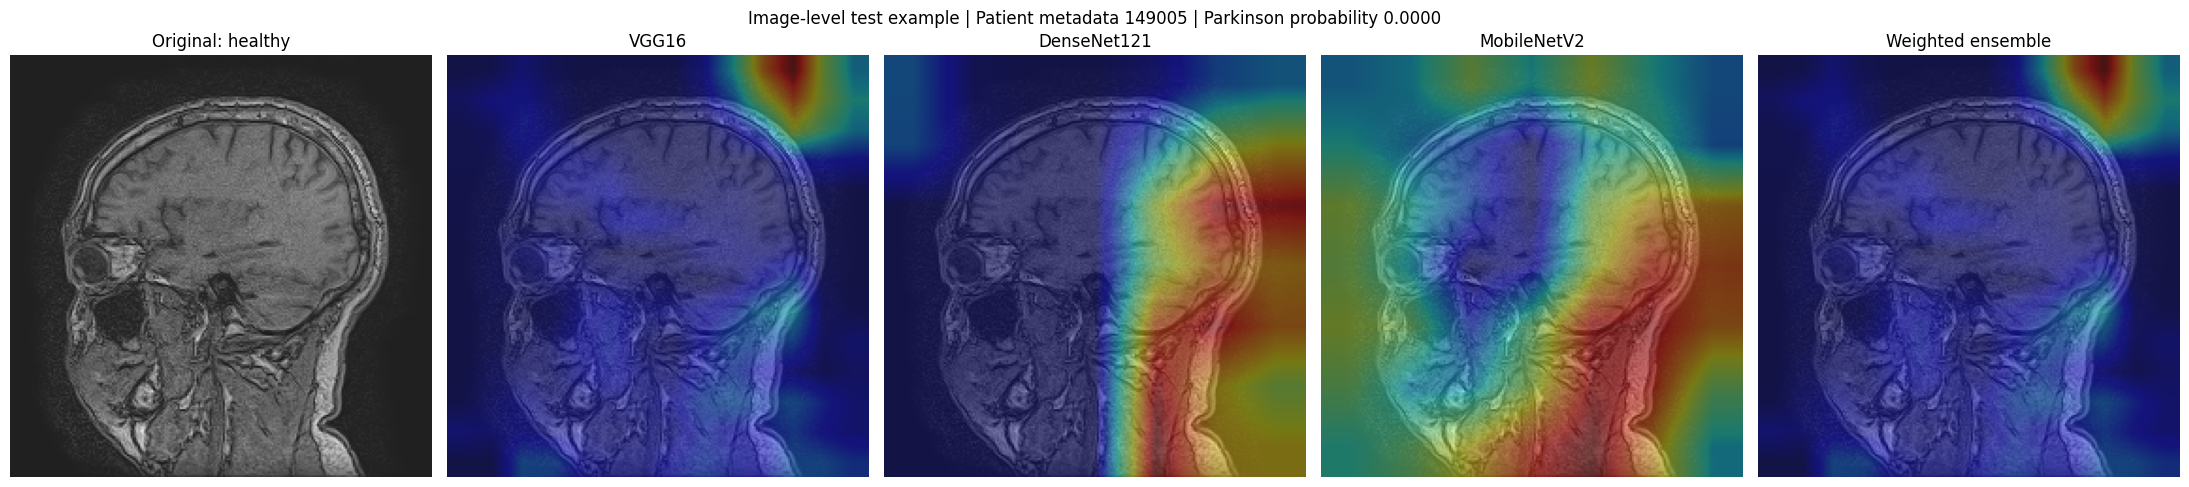

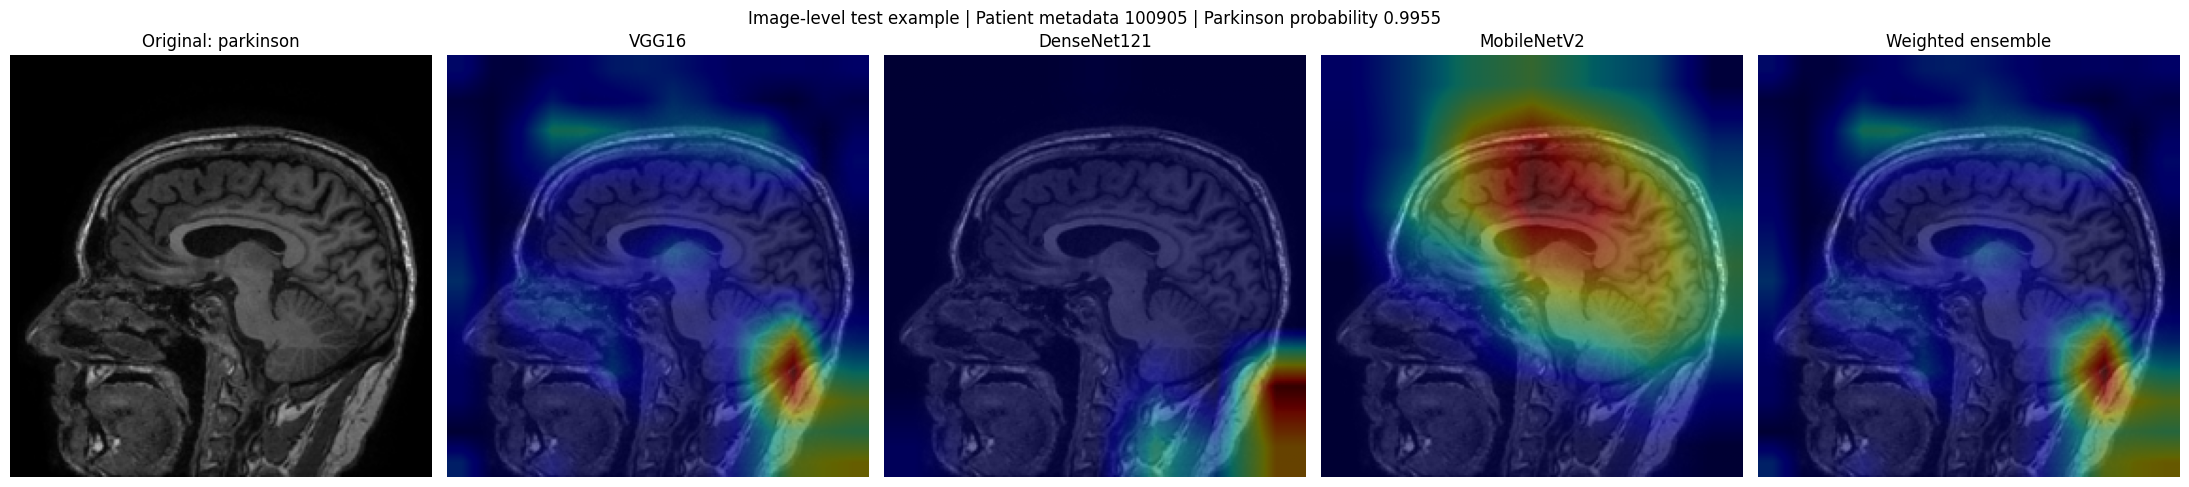

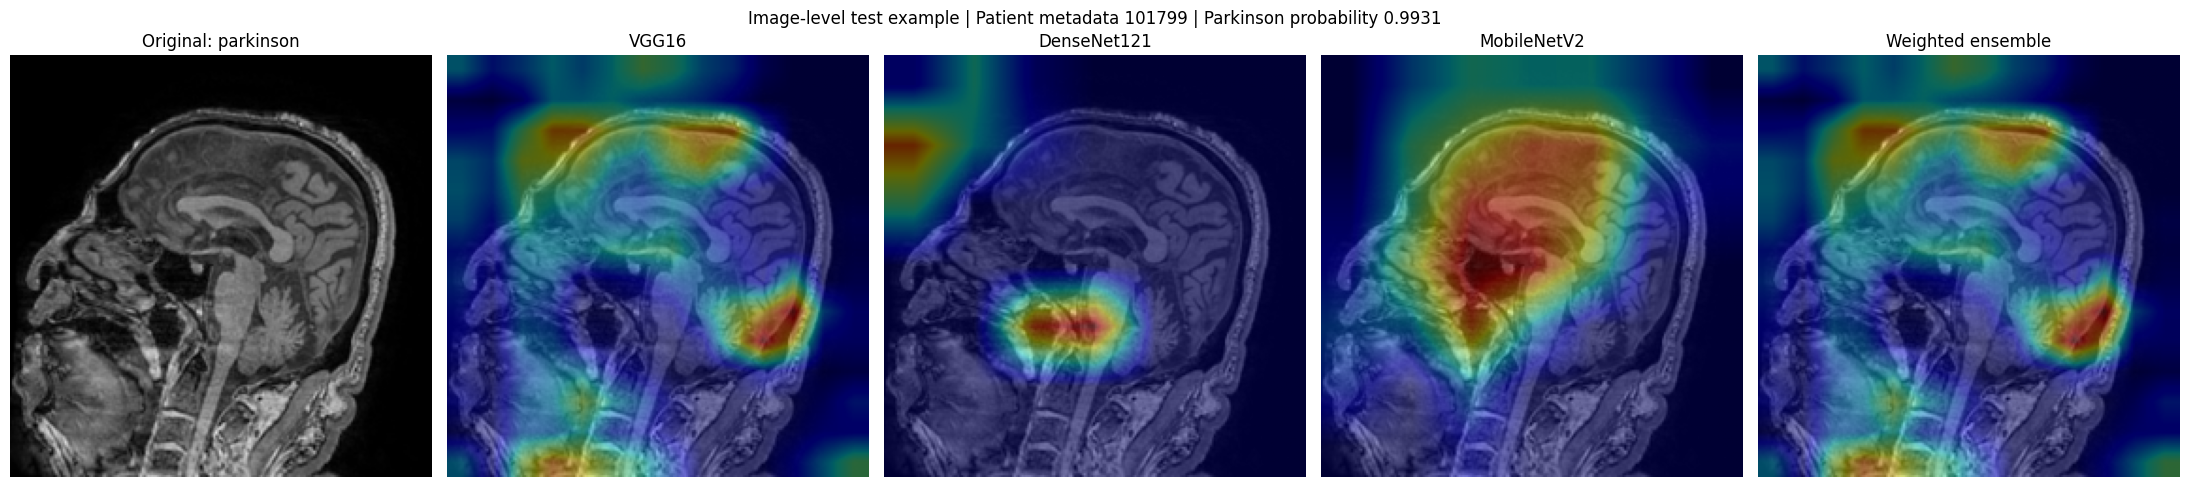

,class,example,patient_id,image_path,png_path,npz_path,vgg16_gradient_norm,densenet121_gradient_norm,mobilenetv2_gradient_norm
0,healthy,1,153233,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,0.467912,5.196637,1.190425
1,healthy,2,149005,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,0.493093,5.834919,1.352621
2,parkinson,1,100905,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,0.498938,4.694227,1.326752
3,parkinson,2,101799,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,/content/drive/MyDrive/New_image_level_updated...,0.493812,5.161632,1.277096


In [28]:
GRADCAM_CONFIG = {
    "VGG16": (
        "vgg16_preprocess",
        ["block5_conv3", "block5_conv2", "block5_conv1"]
    ),
    "DenseNet121": (
        "densenet121_preprocess",
        ["conv5_block16_2_conv", "conv5_block16_1_conv",
         "conv5_block15_2_conv"]
    ),
    "MobileNetV2": (
        "mobilenetv2_preprocess",
        ["Conv_1", "block_16_project", "block_15_project"]
    )
}

HEAD_LAYERS = [
    "global_average_pooling",
    "head_batch_norm",
    "head_dropout_1",
    "head_dense_256",
    "head_dropout_2",
    "prediction"
]

def forward_head(model, backbone_output):
    value = backbone_output
    for layer_name in HEAD_LAYERS:
        layer = model.get_layer(layer_name)
        if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
            value = layer(value, training=False)
        else:
            value = layer(value)
    return value

def gradcam(model, model_name, image_tensor, target_class):
    preprocess_name, candidates = GRADCAM_CONFIG[model_name]
    preprocess = model.get_layer(preprocess_name)
    backbone = find_backbone(model, model_name)
    last_error = None

    for conv_name in candidates:
        try:
            conv_layer = backbone.get_layer(conv_name)
            feature_model = keras.Model(
                backbone.input,
                [conv_layer.output, backbone.output]
            )

            with tf.GradientTape() as tape:
                conv_output, backbone_output = feature_model(
                    preprocess(image_tensor),
                    training=False
                )
                tape.watch(conv_output)
                prediction = forward_head(model, backbone_output)
                probability = tf.clip_by_value(
                    prediction[:, 0],
                    1e-7,
                    1 - 1e-7
                )
                logit = tf.math.log(probability / (1 - probability))
                score = logit if int(target_class) == 1 else -logit

            gradients = tape.gradient(score, conv_output)
            if gradients is None:
                raise ValueError("Gradient is None.")

            gradient_norm = float(
                tf.linalg.global_norm([gradients]).numpy()
            )
            if not np.isfinite(gradient_norm) or gradient_norm <= 1e-12:
                raise ValueError("Invalid gradient norm.")

            pooled = tf.reduce_mean(gradients, axis=(0, 1, 2))
            heatmap = tf.nn.relu(
                tf.reduce_sum(conv_output[0] * pooled, axis=-1)
            ).numpy()

            maximum = float(np.max(heatmap))
            if not np.all(np.isfinite(heatmap)) or maximum <= 1e-12:
                raise ValueError("Empty heatmap.")

            return {
                "heatmap": (heatmap / maximum).astype(np.float32),
                "layer": conv_name,
                "gradient_norm": gradient_norm
            }
        except Exception as error:
            last_error = error

    raise RuntimeError(f"{model_name} Grad-CAM failed: {last_error}")

def load_image_tensor(path):
    image = Image.open(path).convert("RGB").resize(
        (IMG_SIZE[1], IMG_SIZE[0])
    )
    return tf.convert_to_tensor(
        np.asarray(image, dtype=np.float32)[None, ...]
    )

def resize_heatmap(heatmap):
    return tf.image.resize(
        heatmap[None, ..., None],
        IMG_SIZE
    )[0, :, :, 0].numpy()

def overlay_image(path, heatmap, alpha=0.40):
    image = Image.open(path).convert("RGB").resize(
        (IMG_SIZE[1], IMG_SIZE[0])
    )
    original = np.asarray(image, dtype=np.float32) / 255.0
    heatmap = resize_heatmap(heatmap)
    colored = plt.colormaps["jet"](heatmap)[..., :3]
    overlay = np.clip((1 - alpha) * original + alpha * colored, 0, 1)
    return original, overlay, heatmap

best_predictions = artifacts[BEST_METHOD][
    "image_predictions"
].copy()

candidates = best_predictions[
    best_predictions["correct"]
].copy()

candidates["confidence"] = np.where(
    candidates["label"] == 1,
    candidates["probability"],
    1 - candidates["probability"]
)

class_slice_median = candidates.groupby(
    "label"
)["slice_index"].transform("median")

candidates["central_distance"] = (
    candidates["slice_index"]
    - class_slice_median
).abs().fillna(np.inf)

gradcam_rows = []

for target_label, class_name in [(0, "healthy"), (1, "parkinson")]:
    class_candidates = candidates[
        candidates["label"] == target_label
    ].sort_values(
        ["central_distance", "confidence"],
        ascending=[True, False]
    ).drop_duplicates("filepath")

    completed = 0

    for _, row in class_candidates.iterrows():
        try:
            image_tensor = load_image_tensor(row["filepath"])
            branch = {
                name: gradcam(
                    model,
                    name,
                    image_tensor,
                    target_label
                )
                for name, model in base_models.items()
            }

            resized = {
                name: resize_heatmap(result["heatmap"])
                for name, result in branch.items()
            }

            combined = (
                GLOBAL_WEIGHTS[0] * resized["VGG16"]
                + GLOBAL_WEIGHTS[1] * resized["DenseNet121"]
                + GLOBAL_WEIGHTS[2] * resized["MobileNetV2"]
            )
            maximum = float(np.max(combined))
            if not np.all(np.isfinite(combined)) or maximum <= 1e-12:
                raise RuntimeError("Invalid ensemble heatmap.")
            combined = (combined / maximum).astype(np.float32)

            original = np.asarray(
                Image.open(row["filepath"]).convert("RGB").resize(
                    (IMG_SIZE[1], IMG_SIZE[0])
                ),
                dtype=np.float32
            ) / 255.0

            overlays = {}
            for name in BASE_MODEL_NAMES:
                _, overlays[name], _ = overlay_image(
                    row["filepath"],
                    branch[name]["heatmap"]
                )

            ensemble_colored = plt.colormaps["jet"](combined)[..., :3]
            ensemble_overlay = np.clip(
                0.60 * original + 0.40 * ensemble_colored,
                0,
                1
            )

            completed += 1
            figure, axes = plt.subplots(1, 5, figsize=(22, 5))
            axes[0].imshow(original)
            axes[0].set_title(f"Original: {class_name}")
            axes[1].imshow(overlays["VGG16"])
            axes[1].set_title("VGG16")
            axes[2].imshow(overlays["DenseNet121"])
            axes[2].set_title("DenseNet121")
            axes[3].imshow(overlays["MobileNetV2"])
            axes[3].set_title("MobileNetV2")
            axes[4].imshow(ensemble_overlay)
            axes[4].set_title("Weighted ensemble")

            for axis in axes:
                axis.axis("off")

            figure.suptitle(
                f"Image-level test example | Patient metadata {row['patient_id']} | "
                f"Parkinson probability {row['probability']:.4f}"
            )
            figure.tight_layout()

            png_path = GRADCAM_DIR / (
                f"image_level_late_fusion_gradcam_{class_name}_{completed}.png"
            )
            npz_path = GRADCAM_DIR / (
                f"image_level_late_fusion_gradcam_{class_name}_{completed}.npz"
            )

            figure.savefig(png_path, dpi=300, bbox_inches="tight")
            plt.show()
            plt.close(figure)

            np.savez_compressed(
                npz_path,
                vgg16_heatmap=resized["VGG16"],
                densenet121_heatmap=resized["DenseNet121"],
                mobilenetv2_heatmap=resized["MobileNetV2"],
                ensemble_heatmap=combined,
                true_label=np.int32(target_label),
                predicted_label=np.int32(row["predicted_label"]),
                parkinson_probability=np.float32(row["probability"]),
                patient_id=np.array(str(row["patient_id"])),
                image_path=np.array(str(row["filepath"])),
                vgg16_layer=np.array(branch["VGG16"]["layer"]),
                densenet121_layer=np.array(branch["DenseNet121"]["layer"]),
                mobilenetv2_layer=np.array(branch["MobileNetV2"]["layer"]),
                vgg16_gradient_norm=np.float32(
                    branch["VGG16"]["gradient_norm"]
                ),
                densenet121_gradient_norm=np.float32(
                    branch["DenseNet121"]["gradient_norm"]
                ),
                mobilenetv2_gradient_norm=np.float32(
                    branch["MobileNetV2"]["gradient_norm"]
                ),
                global_weights=GLOBAL_WEIGHTS.astype(np.float32),
                evaluation_level=np.array("image_level"),
                best_method=np.array(BEST_METHOD),
                split_fingerprint=np.array(SPLIT_FINGERPRINT)
            )

            gradcam_rows.append({
                "class": class_name,
                "example": completed,
                "patient_id": row["patient_id"],
                "image_path": row["filepath"],
                "png_path": str(png_path),
                "npz_path": str(npz_path),
                "vgg16_gradient_norm": branch["VGG16"]["gradient_norm"],
                "densenet121_gradient_norm": branch["DenseNet121"][
                    "gradient_norm"
                ],
                "mobilenetv2_gradient_norm": branch["MobileNetV2"][
                    "gradient_norm"
                ]
            })

            if completed == 2:
                break

        except Exception as error:
            print("Rejected Grad-CAM candidate:", row["filepath"], error)

    if completed < 2:
        raise RuntimeError(
            f"Only {completed} valid Grad-CAM examples for {class_name}."
        )

gradcam_summary = pd.DataFrame(gradcam_rows)
gradcam_summary.to_csv(TABLES_DIR / "gradcam_summary.csv", index=False)
display(gradcam_summary)

## Final image-level output and NPZ verification

In [29]:
required = [
    IMAGE_SPLIT_PATH,
    MASTER_SPLIT_PATH,
    TABLES_DIR
    / "image_level_late_fusion_comparison.csv",
    TABLES_DIR
    / "image_level_late_fusion_comparison.xlsx",
    TABLES_DIR
    / "late_fusion_weights.csv",
    TABLES_DIR
    / "gradcam_summary.csv",
    IMAGE_ROC_GRAPH,
    COMBINED_IMAGE_ROC_NPZ,
    BEST_IMAGE_ALIAS,
    HISTORY_DIR
    / "global_trainable_weight_fusion_history.csv",
    HISTORY_DIR
    / "sample_wise_attention_late_fusion_history.csv",
]

for model_name in BASE_MODEL_NAMES:
    required.append(
        MODELS_DIR
        / (
            f"{model_name.lower()}_"
            "image_level_best.keras"
        )
    )

for artifact in artifacts.values():
    required.extend(
        [
            Path(
                artifact[
                    "image_npz"
                ]
            ),
            Path(
                artifact[
                    "prediction_path"
                ]
            ),
            Path(
                artifact[
                    "report_path"
                ]
            ),
            Path(
                artifact[
                    "confusion_path"
                ]
            ),
        ]
    )

for class_name in [
    "healthy",
    "parkinson",
]:
    for example in [1, 2]:
        required.extend(
            [
                GRADCAM_DIR
                / (
                    "image_level_late_fusion_"
                    f"gradcam_{class_name}_"
                    f"{example}.png"
                ),
                GRADCAM_DIR
                / (
                    "image_level_late_fusion_"
                    f"gradcam_{class_name}_"
                    f"{example}.npz"
                ),
            ]
        )


verification = []

for path in required:
    path = Path(path)

    row = {
        "filename": path.name,
        "full_path": str(path),
        "exists": path.exists(),
        "size_bytes": (
            path.stat().st_size
            if path.exists()
            else 0
        ),
        "npz_keys": "",
        "npz_loads_successfully": "",
    }

    if (
        path.exists()
        and path.suffix == ".npz"
    ):
        try:
            with np.load(
                path,
                allow_pickle=False,
            ) as data:
                row[
                    "npz_keys"
                ] = ", ".join(
                    data.files
                )
                row[
                    "npz_loads_successfully"
                ] = True
        except Exception as error:
            row[
                "npz_loads_successfully"
            ] = False
            row["npz_error"] = str(
                error
            )

    verification.append(row)


verification_df = pd.DataFrame(
    verification
)

verification_df.to_csv(
    TABLES_DIR
    / "final_image_level_output_verification.csv",
    index=False,
)

display(verification_df)

if not verification_df[
    "exists"
].all():
    missing_files = (
        verification_df[
            ~verification_df["exists"]
        ]["full_path"].tolist()
    )

    raise RuntimeError(
        "Some required outputs are missing: "
        f"{missing_files}"
    )

npz_rows = verification_df[
    verification_df[
        "filename"
    ].str.endswith(".npz")
]

if (
    not npz_rows.empty
    and not npz_rows[
        "npz_loads_successfully"
    ].astype(bool).all()
):
    raise RuntimeError(
        "At least one required NPZ "
        "file failed to load."
    )


if TOTAL_BASE_MODEL_EPOCHS != 35:
    raise RuntimeError(
        "The image-level CNN schedule is not 35 epochs."
    )

if GLOBAL_FUSION_EPOCHS != 35:
    raise RuntimeError(
        "Global trainable-weight fusion is not configured for 35 epochs."
    )

if ATTENTION_FUSION_EPOCHS != 35:
    raise RuntimeError(
        "Attention late fusion is not configured for 35 epochs."
    )

summary = {
    "experiment_level": "image",
    "split_fingerprint": (
        SPLIT_FINGERPRINT
    ),
    "total_images": int(
        len(master_df)
    ),
    "total_unique_patients": int(
        master_df[
            "patient_id"
        ].nunique()
    ),
    "train_images": int(
        len(train_df)
    ),
    "development_images": int(
        len(development_df)
    ),
    "test_images": int(
        len(test_df)
    ),
    "image_overlap": {
        "train_development": 0,
        "train_test": 0,
        "development_test": 0,
    },
    "patient_overlap_allowed": (
        patient_overlap_summary
    ),
    "include_top": False,
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "total_base_model_epochs": TOTAL_BASE_MODEL_EPOCHS,
    "global_fusion_epochs": GLOBAL_FUSION_EPOCHS,
    "attention_fusion_epochs": ATTENTION_FUSION_EPOCHS,
    "stacking_method": "logistic_regression",
    "best_method": BEST_METHOD,
    "best_metrics": (
        artifacts[
            BEST_METHOD
        ]["result"]
    ),
    "manual_weights": (
        MANUAL_WEIGHTS.tolist()
    ),
    "grid_weights": (
        GRID_WEIGHTS.tolist()
    ),
    "global_weights": (
        GLOBAL_WEIGHTS.tolist()
    ),
}


(
    SAVE_ROOT
    / "image_level_experiment_summary.json"
).write_text(
    json.dumps(
        summary,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    json.dumps(
        summary,
        indent=2,
    )
)
print(
    "All image-level outputs exist."
)
print(
    "Output folder:",
    SAVE_ROOT,
)

,filename,full_path,exists,size_bytes,npz_keys,npz_loads_successfully
0,image_level_split_assignments.csv,/content/drive/MyDrive/New_image_level_updated...,True,4016716,,
1,parkinson_master_image_level_split.csv,/content/drive/MyDrive/New_image_level_updated...,True,4016716,,
2,image_level_late_fusion_comparison.csv,/content/drive/MyDrive/New_image_level_updated...,True,1666,,
3,image_level_late_fusion_comparison.xlsx,/content/drive/MyDrive/New_image_level_updated...,True,5974,,
4,late_fusion_weights.csv,/content/drive/MyDrive/New_image_level_updated...,True,226,,
5,gradcam_summary.csv,/content/drive/MyDrive/New_image_level_updated...,True,2693,,
6,image_level_roc_comparison.png,/content/drive/MyDrive/New_image_level_updated...,True,278932,,
7,all_late_fusion_image_roc_data.npz,/content/drive/MyDrive/New_image_level_updated...,True,140475,"image_paths, y_true, split_fingerprint, evalua...",True
8,best_late_fusion_image_roc_data.npz,/content/drive/MyDrive/New_image_level_updated...,True,56172,"image_paths, y_true, y_prob, y_probability, y_...",True
9,global_trainable_weight_fusion_history.csv,/content/drive/MyDrive/New_image_level_updated...,True,3515,,


{
  "experiment_level": "image",
  "split_fingerprint": "fcc9976abdc6803bf00c",
  "total_images": 11120,
  "total_unique_patients": 52,
  "train_images": 6672,
  "development_images": 2224,
  "test_images": 2224,
  "image_overlap": {
    "train_development": 0,
    "train_test": 0,
    "development_test": 0
  },
  "patient_overlap_allowed": {
    "train_development": 52,
    "train_test": 52,
    "development_test": 52
  },
  "include_top": false,
  "head_epochs": 10,
  "fine_tune_epochs": 25,
  "total_base_model_epochs": 35,
  "global_fusion_epochs": 35,
  "attention_fusion_epochs": 35,
  "stacking_method": "logistic_regression",
  "best_method": "Development Grid Weighted Late Fusion",
  "best_metrics": {
    "Method": "Development Grid Weighted Late Fusion",
    "Evaluation Level": "Image",
    "Test Images": 2224,
    "Accuracy": 0.989658273381295,
    "Precision": 0.991869918699187,
    "Recall": 0.987410071942446,
    "Specificity": 0.9919064748201439,
    "F1": 0.989634970707525

## Colab run instructions

1. Select a GPU runtime.
2. Confirm that `ZIP_PATH` points to `Parkinson_dataset.zip`.
3. Run all cells from the beginning.
4. Each base CNN uses:
   - `include_top=False`
   - 10 frozen-backbone epochs
   - 25 partial fine-tuning epochs
   - 35 total epochs
5. Global trainable-weight fusion uses 35 epochs.
6. Sample-wise attention late fusion uses 35 epochs.
7. Logistic-regression stacking is fitted on development-image
   probabilities and does not use CNN epochs.
8. Training checkpoints are written locally under `/content` and copied
   to Drive with retry protection.
9. Use the image-level ROC NPZ files only for image-level reporting.
10. Keep image-level and patient-level ROC curves in separate figures.

Output directory:

```text
/content/drive/MyDrive/Late_fusion_image_level/
Late_fusion_data_save_here/
```